# ***📥 Notebook 3 — Modelling***


### What this notebook does:
- Loads the dataset from `data/processed/processed_data.csv`
- Scaling
- Modelling
- Comparison 
---


# ***Libraries***

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error, \
    accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree

# ***Path***

In [27]:
INPUT_FILE = r'../data/processed/processed_data.csv'

OUTPUT_DIR = r'..\outputs\plots\\'

def save_plot(filename):
    path = OUTPUT_DIR + filename
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved to -> {path}')

# ***DATASET***

In [28]:
df = pd.read_csv(INPUT_FILE)
df.head()


,Order_ID,Customer_Location,Restaurant_Location,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,...,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,Customer_Lat,Customer_Lon,Restaurant_Lat,Restaurant_Lon,distance_calculated,is_peak_hour
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,1,4,1,4.1,3.0,26.22,...,0,0,0,1,17.030479,79.743077,12.358515,85.100083,775.651198,0
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,1,8,0,4.5,4.2,62.61,...,1,0,0,1,15.398319,86.639122,14.174874,77.025606,1042.385597,1
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,1,9,2,3.3,3.4,48.43,...,1,0,1,0,15.687342,83.888808,19.594748,82.048482,476.220706,1
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,0,2,1,3.2,3.7,111.63,...,0,0,1,0,20.415599,78.046984,16.915906,78.278698,389.912629,1
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,2,6,0,3.5,2.8,32.38,...,1,0,1,0,14.786904,78.706532,15.206038,86.203182,806.505886,1


In [29]:
df.drop(columns=['Order_ID', 'Customer_Location', 'Restaurant_Location',
                  'Customer_Lat', 'Customer_Lon', 'Restaurant_Lat', 'Restaurant_Lon'], inplace=True)
df.head()

,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Rush_Hour,...,Weather_Conditions_Sunny,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,distance_calculated,is_peak_hour
0,1.57,1,4,1,4.1,3.0,26.22,1321.10,81.54,0,...,0,1,0,0,0,0,0,1,775.651198,0
1,21.32,1,8,0,4.5,4.2,62.61,152.21,29.02,1,...,0,0,0,0,1,0,0,1,1042.385597,1
2,6.95,1,9,2,3.3,3.4,48.43,1644.38,64.17,1,...,0,0,0,0,1,0,1,0,476.220706,1
3,13.79,0,2,1,3.2,3.7,111.63,541.25,79.23,1,...,0,0,1,0,0,0,1,0,389.912629,1
4,6.72,2,6,0,3.5,2.8,32.38,619.81,2.34,1,...,0,0,0,0,1,0,1,0,806.505886,1


# ***Correlation***

In [30]:
df.corr()['Delivery_Time']

Distance                     -0.075143
Traffic_Conditions           -0.055840
Delivery_Person_Experience   -0.019098
Order_Priority               -0.004982
Restaurant_Rating            -0.091855
Customer_Rating              -0.021952
Delivery_Time                 1.000000
Order_Cost                   -0.009307
Tip_Amount                   -0.029154
Rush_Hour                    -0.015302
Weather_Conditions_Cloudy    -0.012272
Weather_Conditions_Rainy      0.054402
Weather_Conditions_Snowy     -0.024621
Weather_Conditions_Sunny     -0.020492
Order_Time_Afternoon          0.006363
Order_Time_Evening           -0.004021
Order_Time_Morning            0.011984
Order_Time_Night             -0.013972
Vehicle_Type_Bicycle          0.093194
Vehicle_Type_Bike            -0.091859
Vehicle_Type_Car             -0.001372
distance_calculated          -0.170822
is_peak_hour                 -0.015302
Name: Delivery_Time, dtype: float64

Saved to -> ..\outputs\plots\\correlation.png


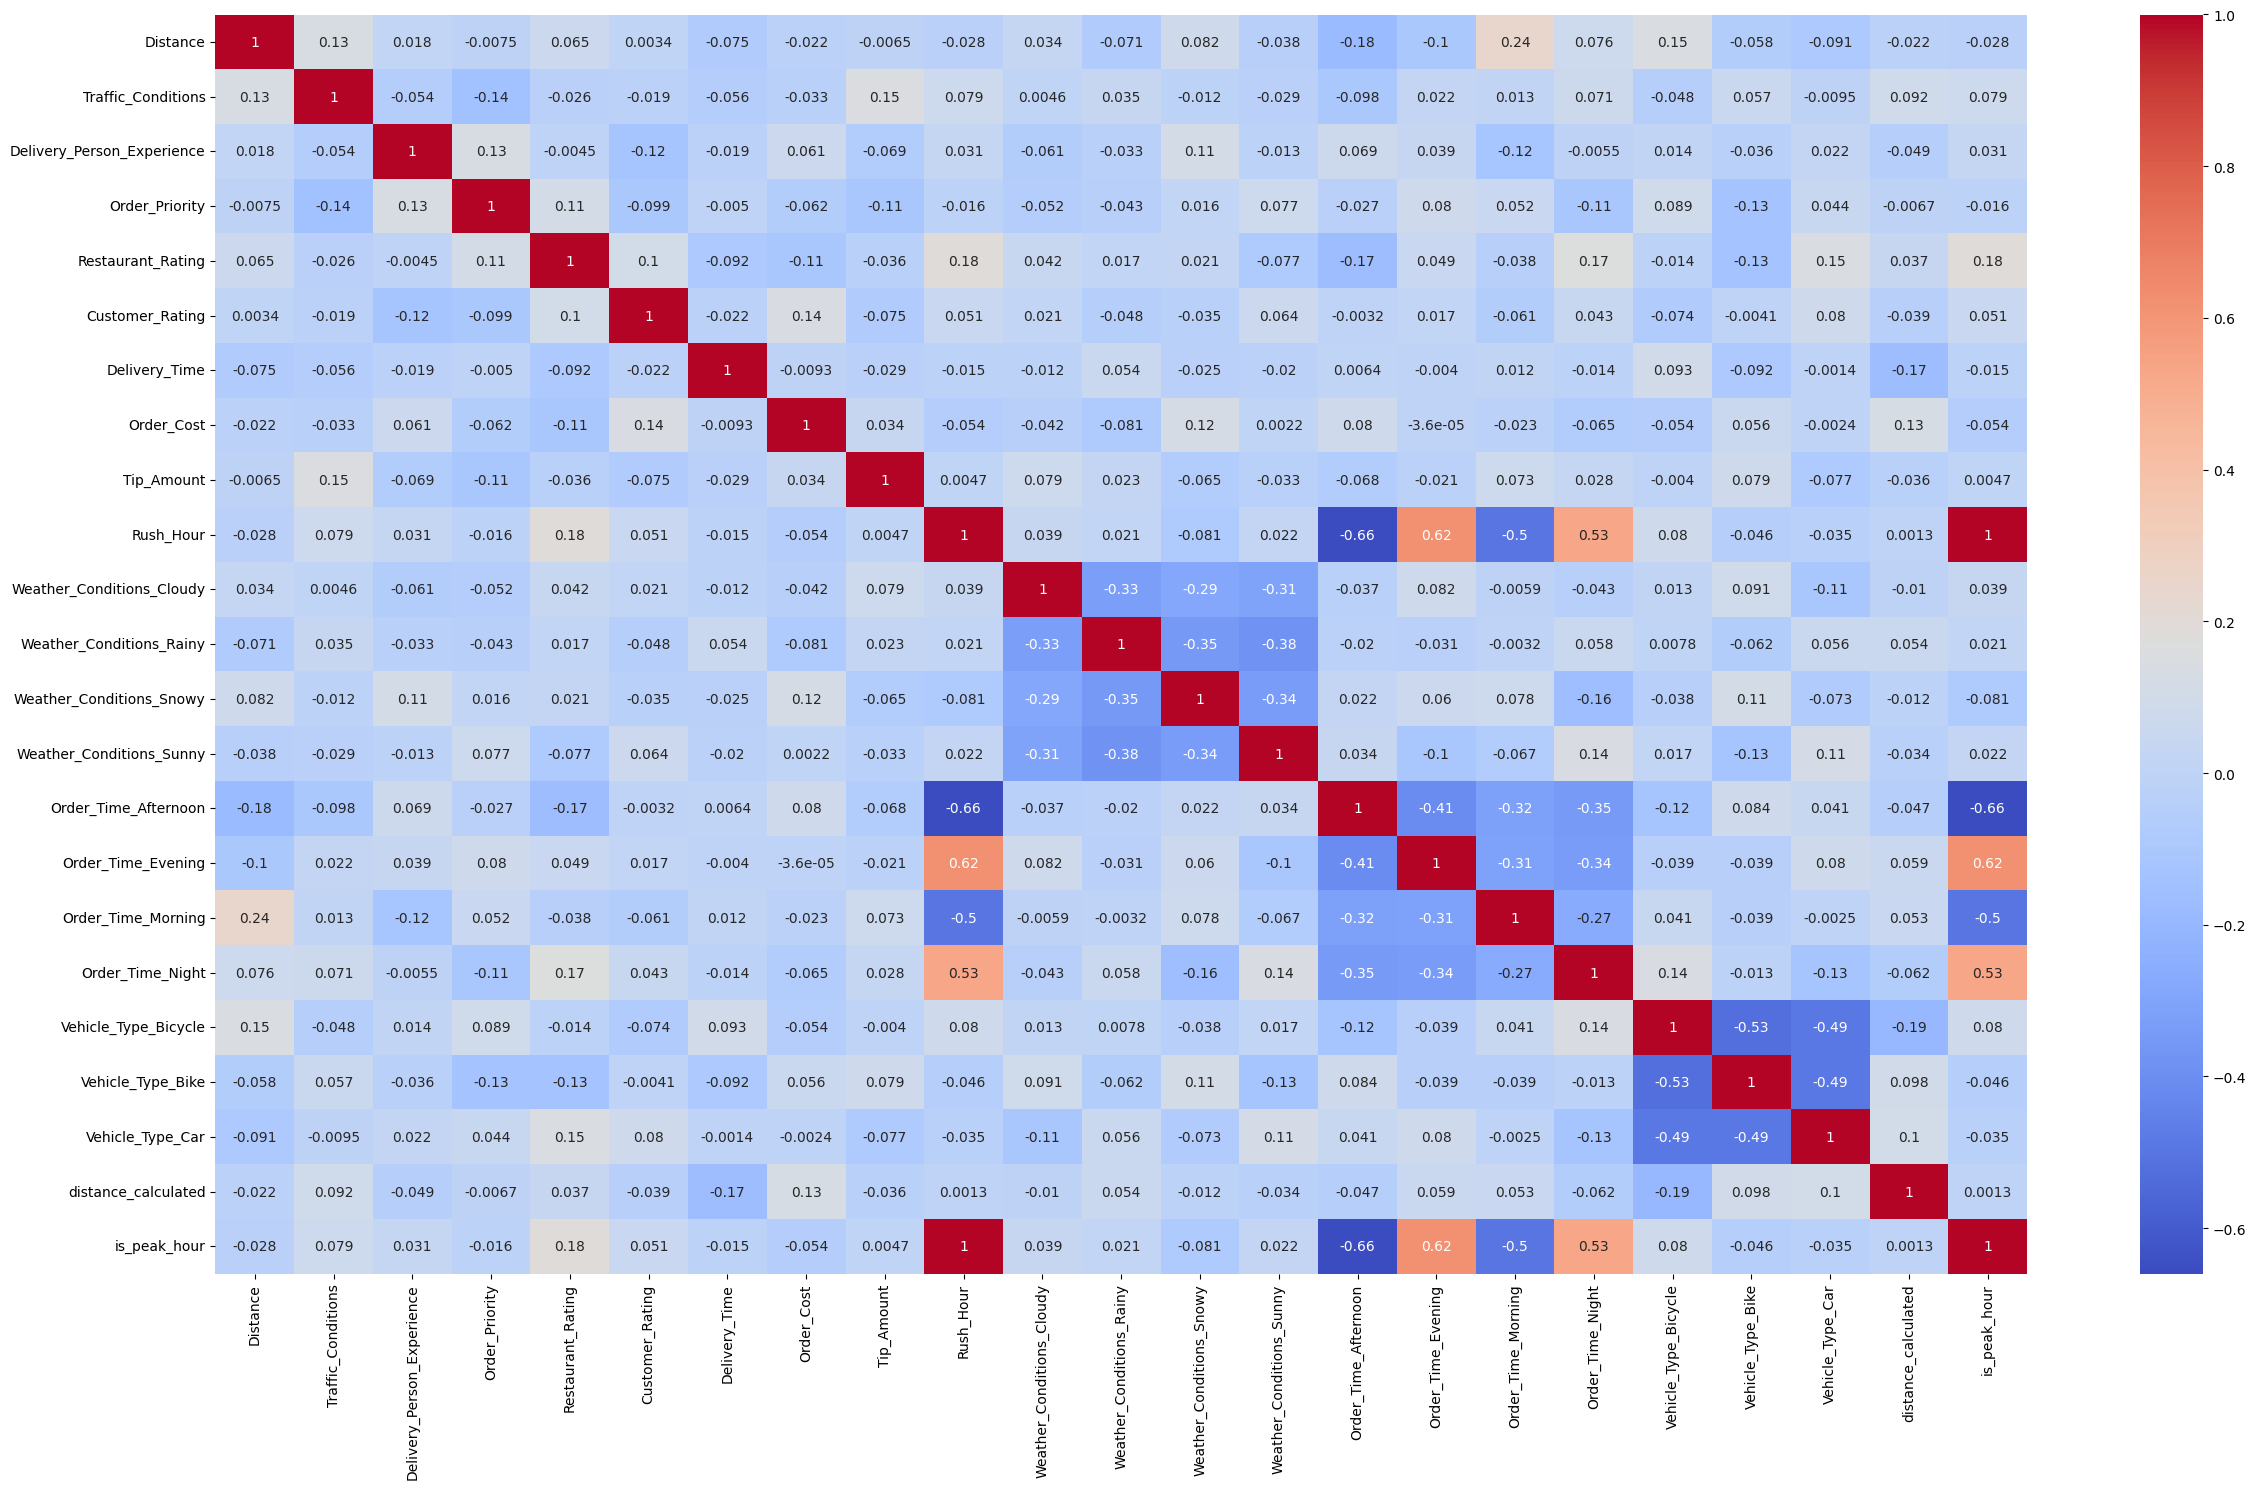

In [31]:
plt.figure(figsize=(25,15))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.tight_layout()
save_plot('correlation.png')
plt.show()

# ***Linear Regression***

In [32]:
print('Declaring features and target..')
x = df.drop(columns=['Delivery_Time'])
y = df['Delivery_Time']
print('Declaration completed..')

Declaring features and target..
Declaration completed..


In [33]:
print(f'Name of Columns taken as features: {x.columns}')
print(f'Number of columns taken: {x.shape[1]}')



Name of Columns taken as features: Index(['Distance', 'Traffic_Conditions', 'Delivery_Person_Experience',
       'Order_Priority', 'Restaurant_Rating', 'Customer_Rating', 'Order_Cost',
       'Tip_Amount', 'Rush_Hour', 'Weather_Conditions_Cloudy',
       'Weather_Conditions_Rainy', 'Weather_Conditions_Snowy',
       'Weather_Conditions_Sunny', 'Order_Time_Afternoon',
       'Order_Time_Evening', 'Order_Time_Morning', 'Order_Time_Night',
       'Vehicle_Type_Bicycle', 'Vehicle_Type_Bike', 'Vehicle_Type_Car',
       'distance_calculated', 'is_peak_hour'],
      dtype='str')
Number of columns taken: 22


In [34]:
print('Performing the split..')
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print('Split completed..')
print('-'*20)
# Using standardization on feature
print('Performing standardization..')
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print('Standardization completed..')
print('-'*20)
print('Creating model..')
model = LinearRegression()

model.fit(x_train, y_train)
print('Model created..')
print('-'*20)

print(f'Constant = {model.intercept_}')
print(f'Slope = {model.coef_}')
print('-'*20)
print('Predicting....')
pred_linear = model.predict(x_test)
print('Prediction done...')
print('-'*20)


Performing the split..
Split completed..
--------------------
Performing standardization..
Standardization completed..
--------------------
Creating model..
Model created..
--------------------
Constant = 70.702625
Slope = [-1.35960495 -1.43453847 -2.81243393 -0.67450233 -1.93985155 -0.91700839
 -0.75205353 -0.68536564 -0.10922578 -1.11975907  2.14469403 -0.54431932
 -0.57128285 -0.88028053  0.13500033  1.18240897 -0.28246571  1.87424969
 -1.7601818  -0.08749182 -3.12247116 -0.10922578]
--------------------
Predicting....
Prediction done...
--------------------


Saved to -> ..\outputs\plots\\Distance_vs_deliverytime_scatterplot.png


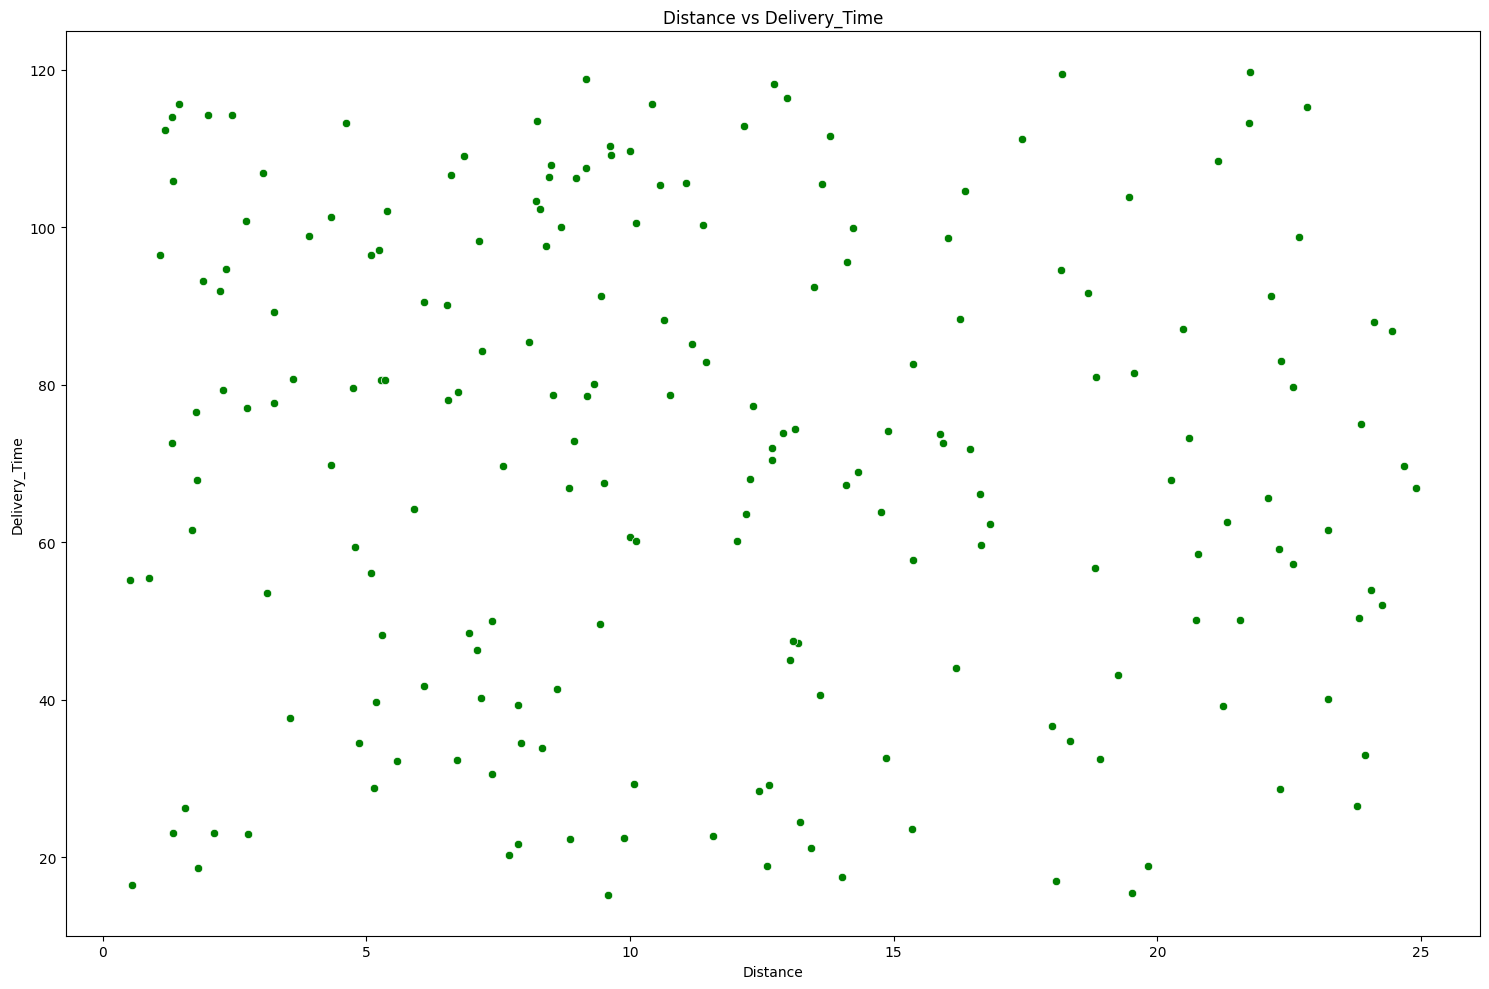

Saved to -> ..\outputs\plots\\Traffic_Conditions_vs_deliverytime_scatterplot.png


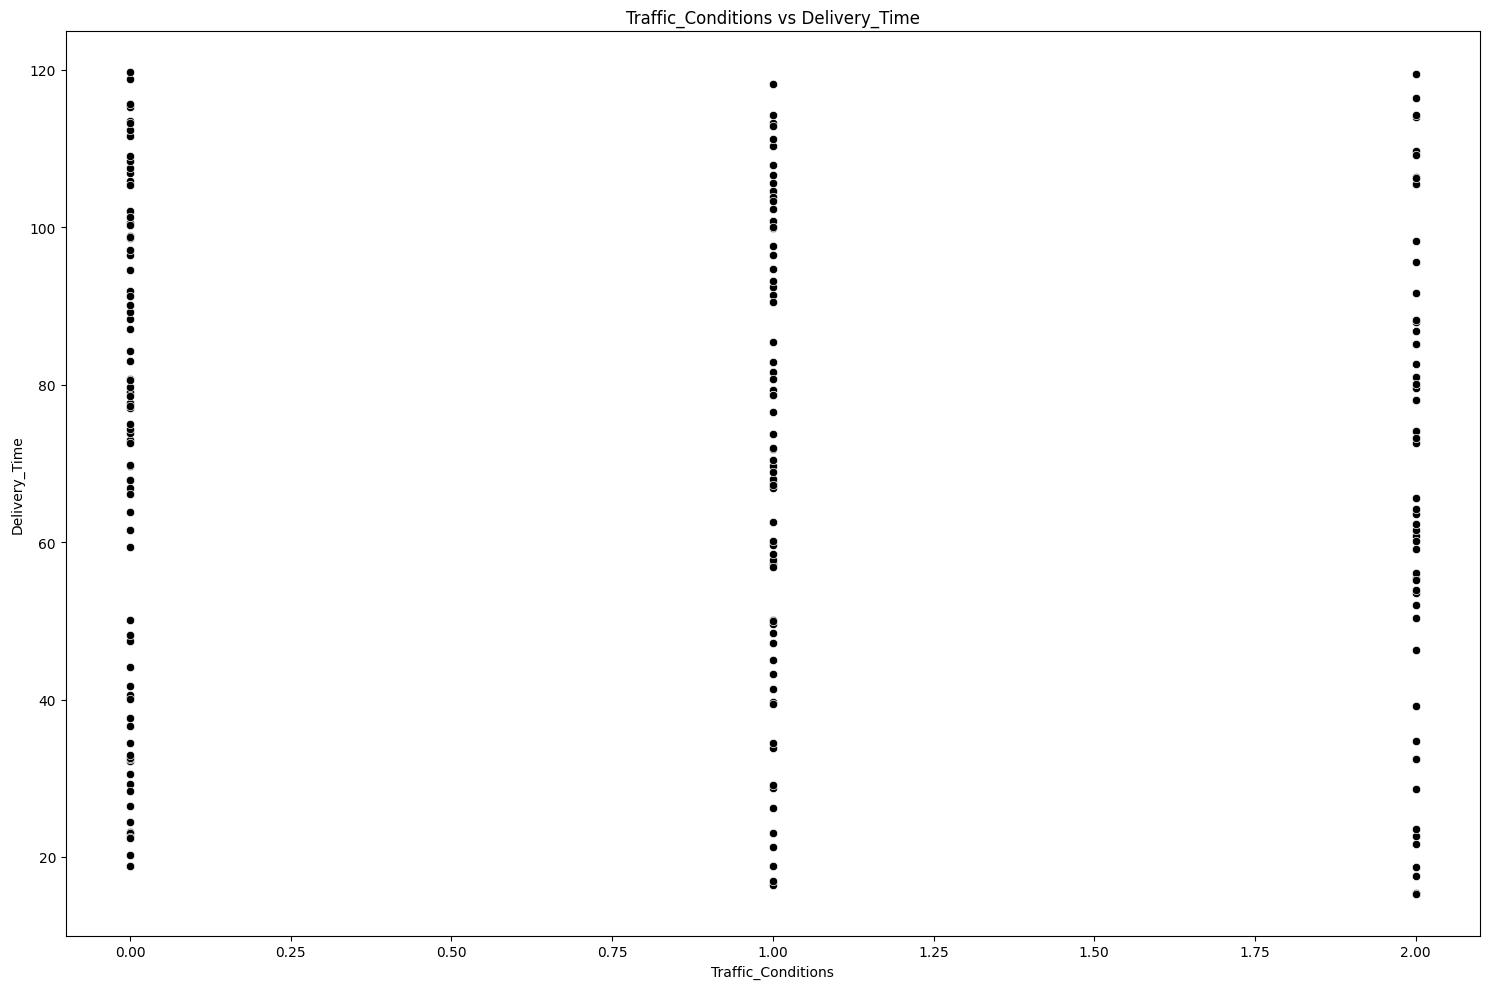

Saved to -> ..\outputs\plots\\Delivery_Person_Experience_vs_deliverytime_scatterplot.png


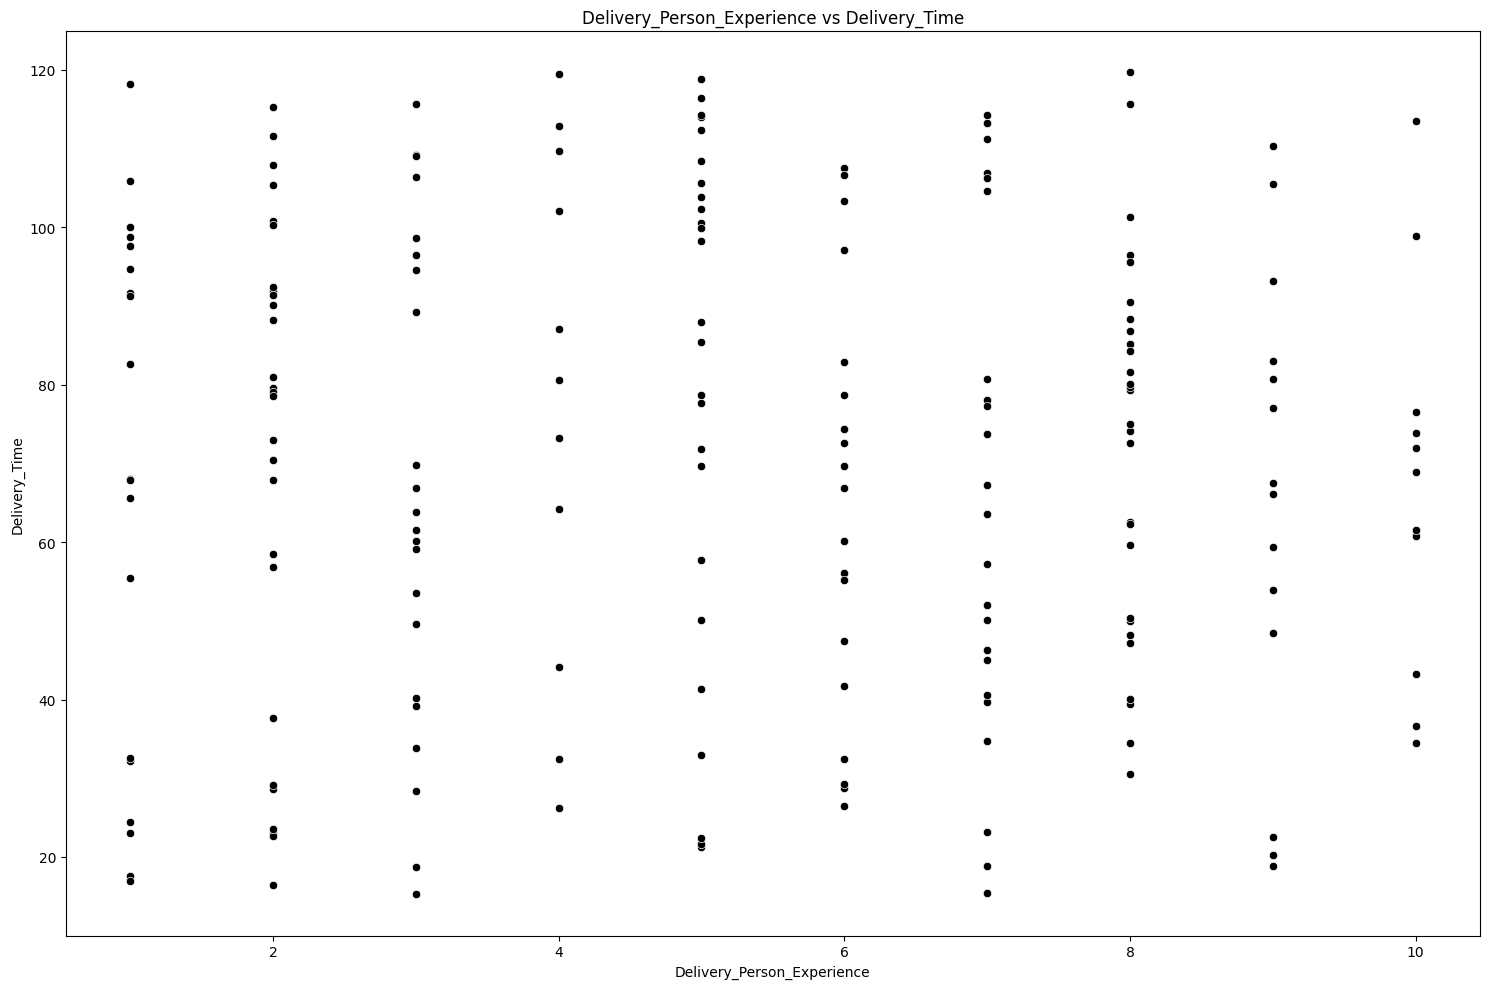

Saved to -> ..\outputs\plots\\Order_Priority_vs_deliverytime_scatterplot.png


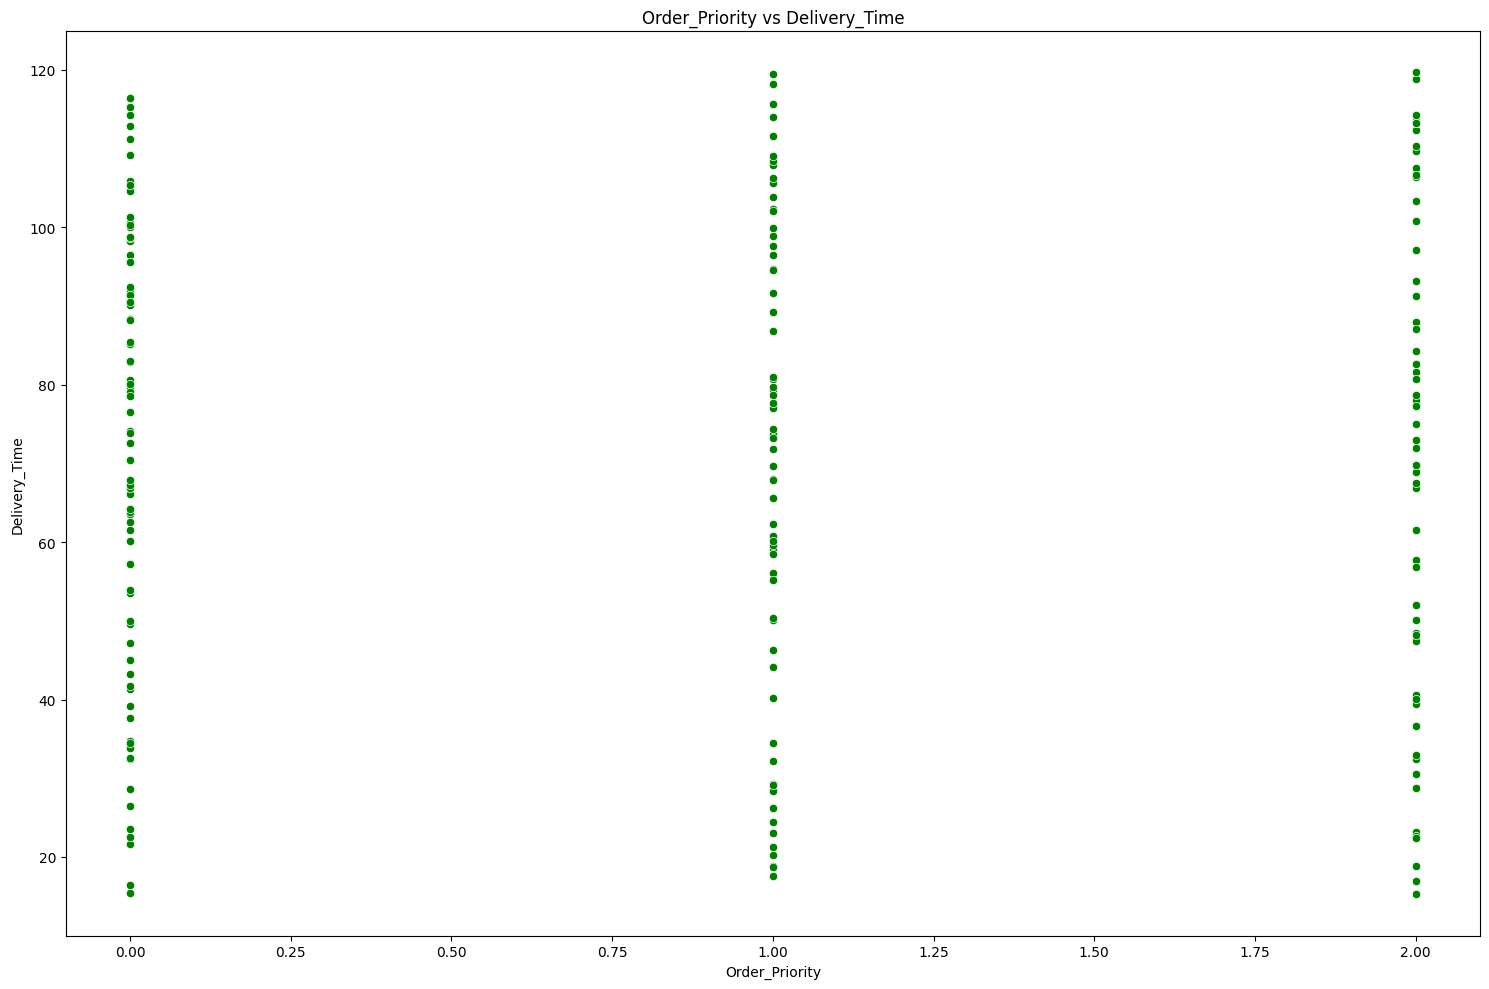

Saved to -> ..\outputs\plots\\Restaurant_Rating_vs_deliverytime_scatterplot.png


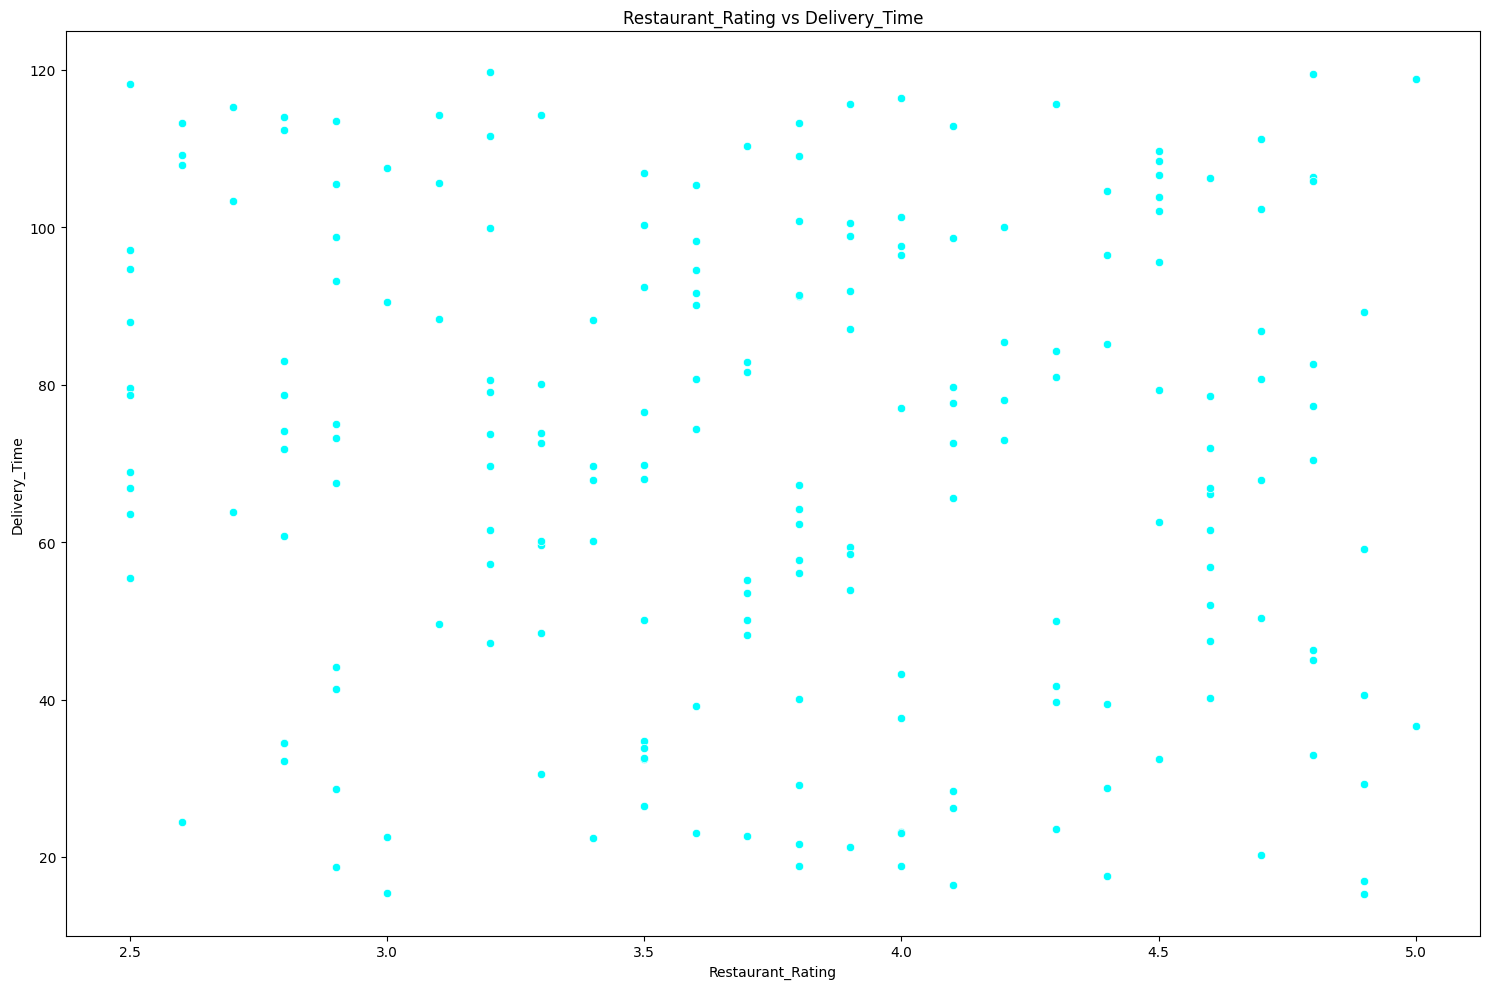

Saved to -> ..\outputs\plots\\Customer_Rating_vs_deliverytime_scatterplot.png


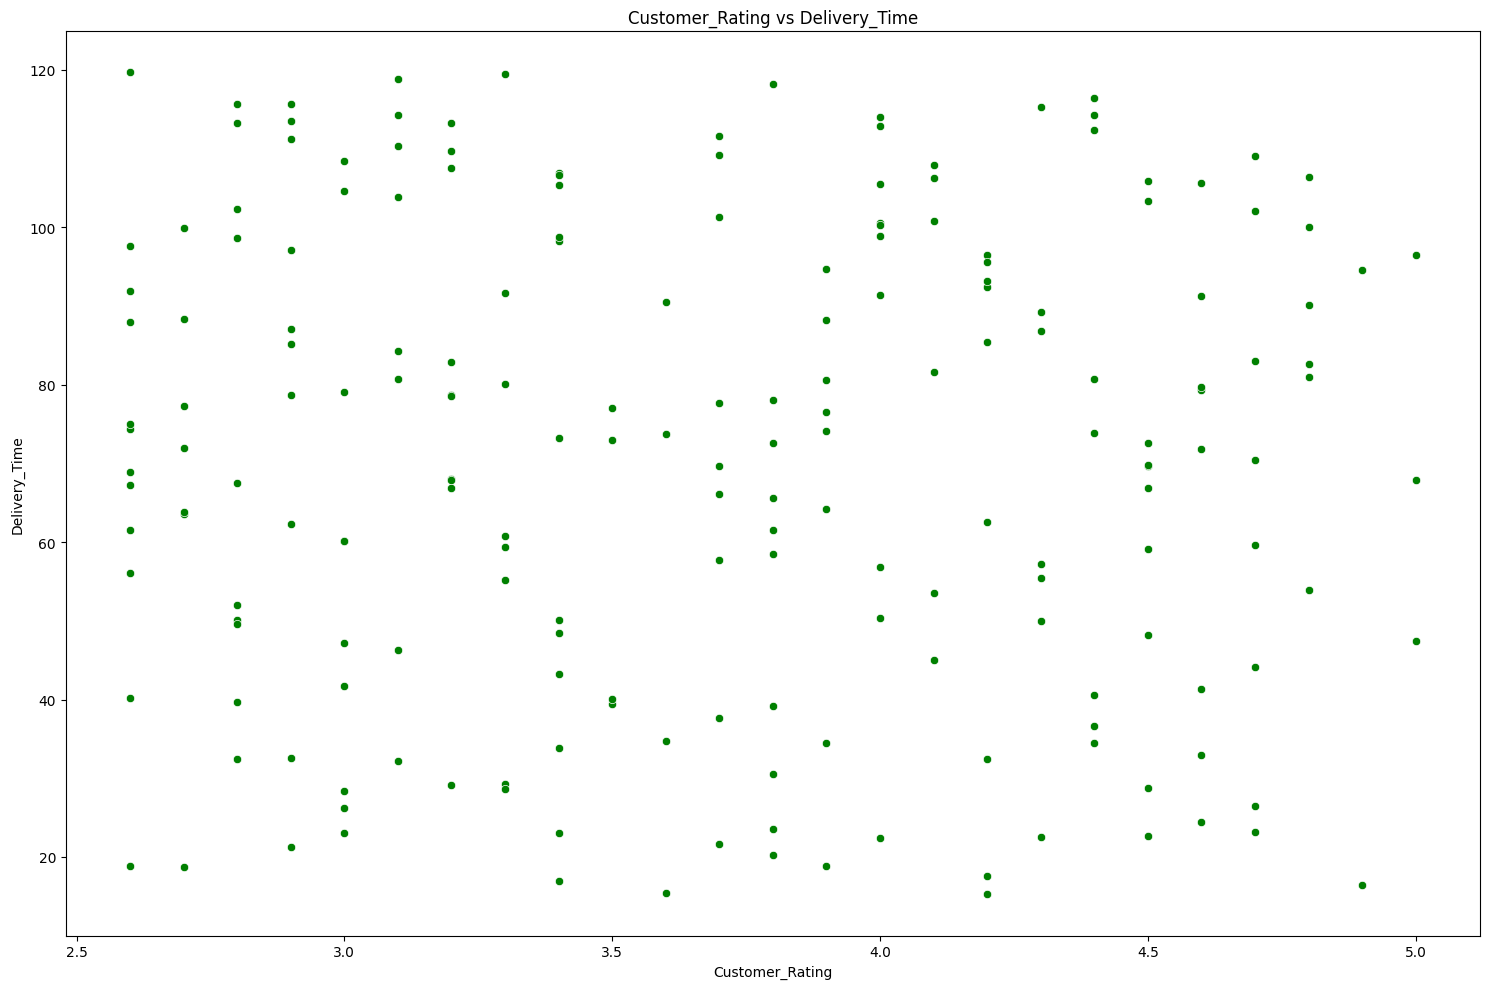

Saved to -> ..\outputs\plots\\Order_Cost_vs_deliverytime_scatterplot.png


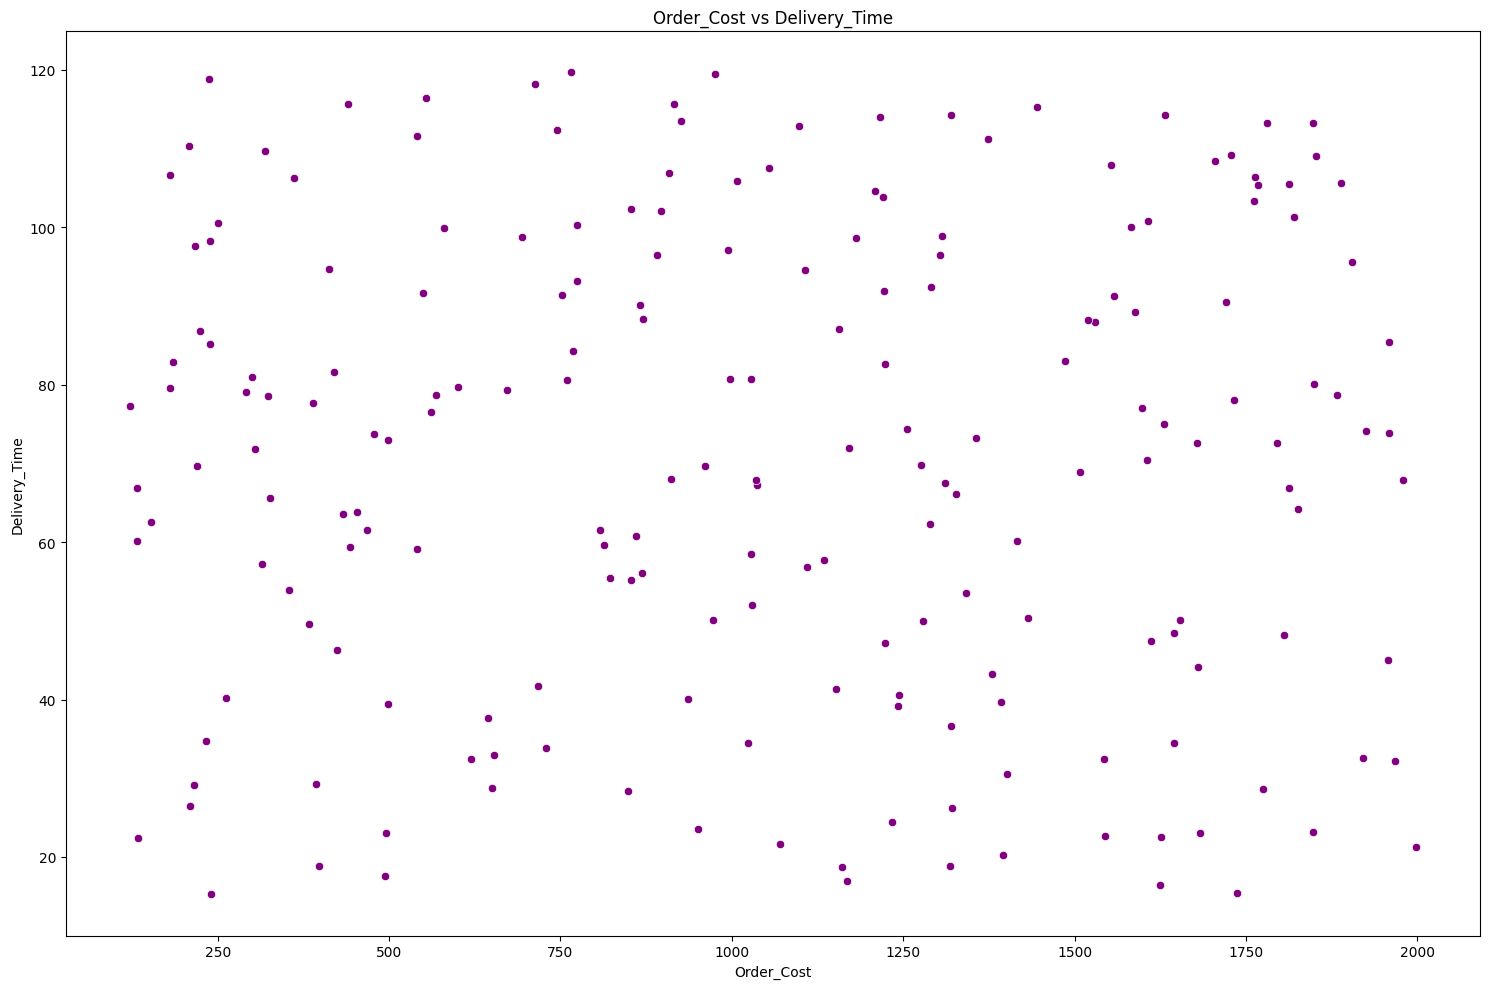

Saved to -> ..\outputs\plots\\Tip_Amount_vs_deliverytime_scatterplot.png


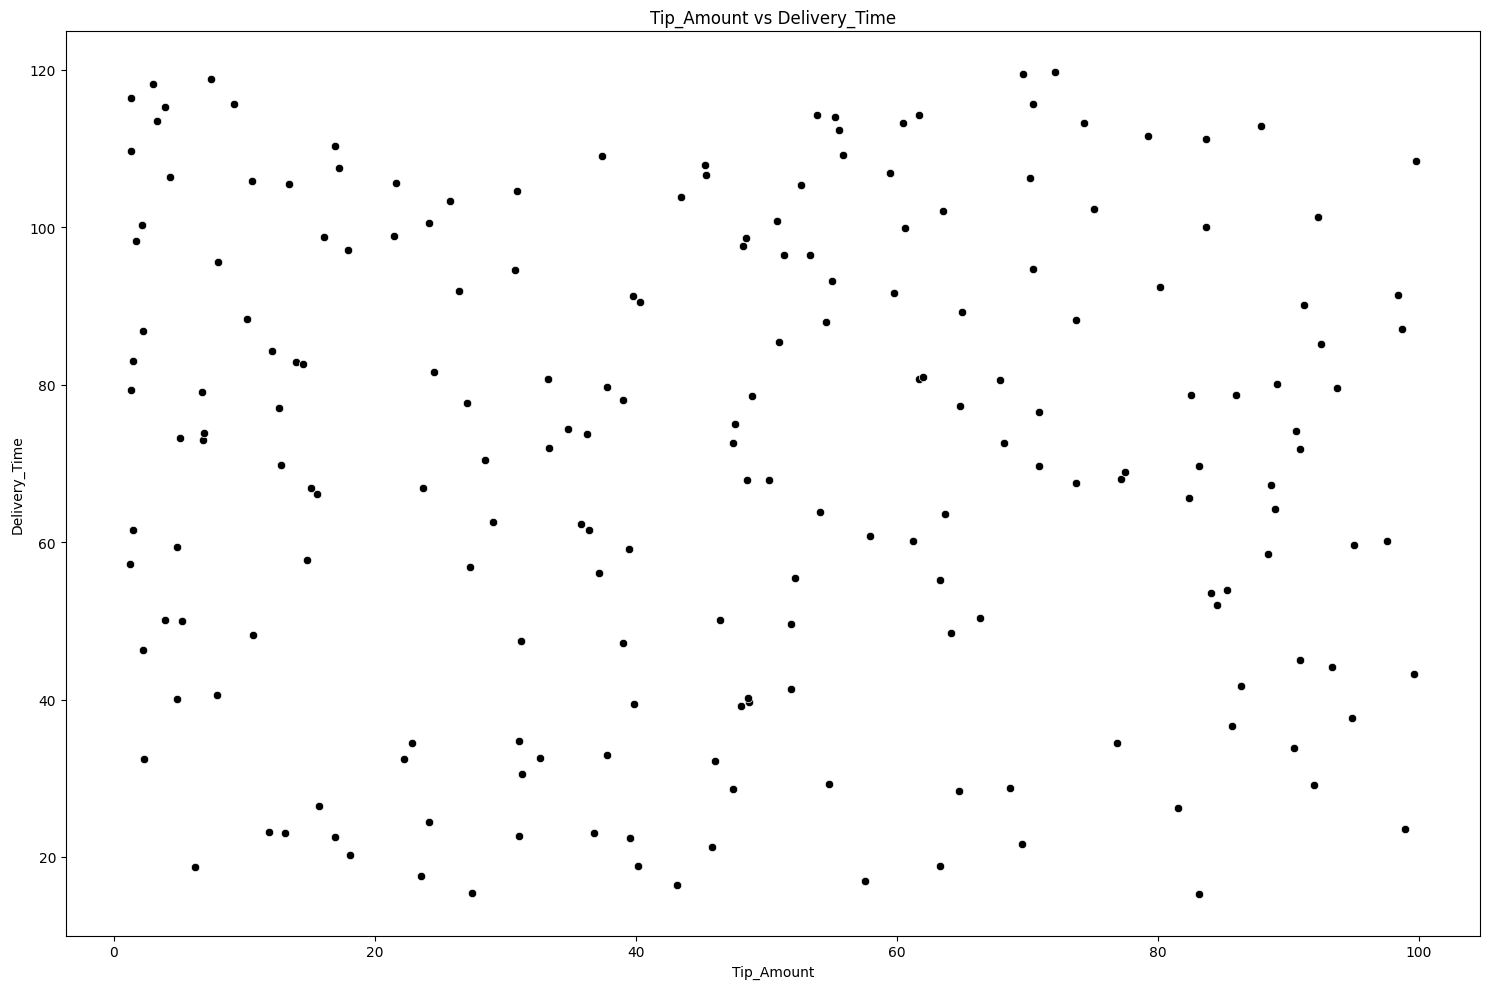

Saved to -> ..\outputs\plots\\Rush_Hour_vs_deliverytime_scatterplot.png


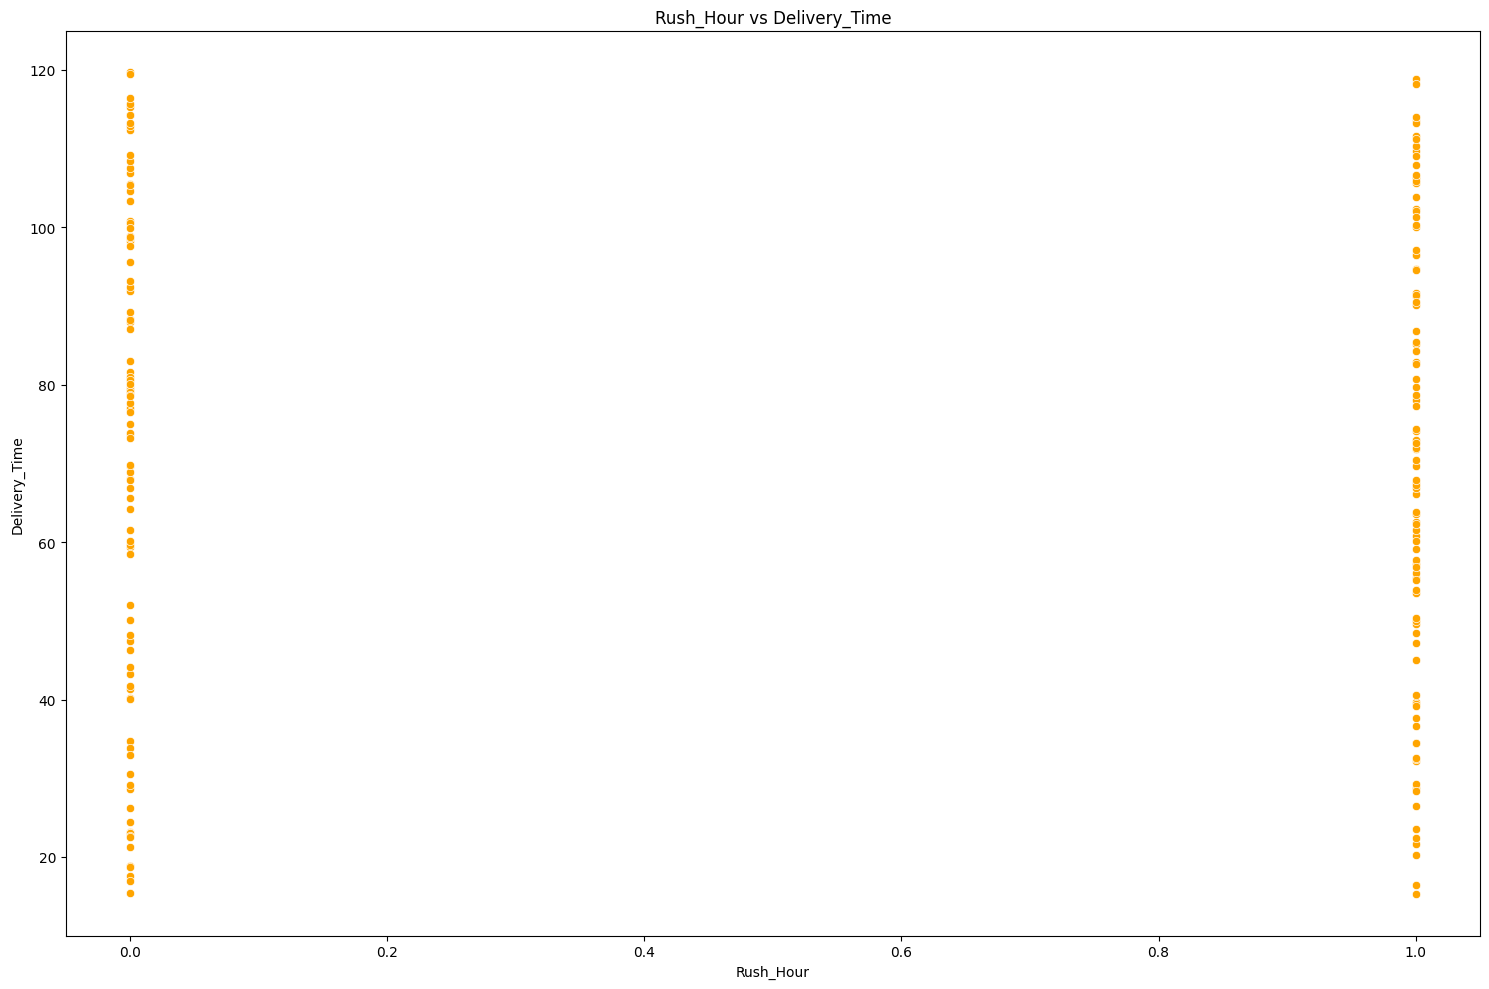

Saved to -> ..\outputs\plots\\Weather_Conditions_Cloudy_vs_deliverytime_scatterplot.png


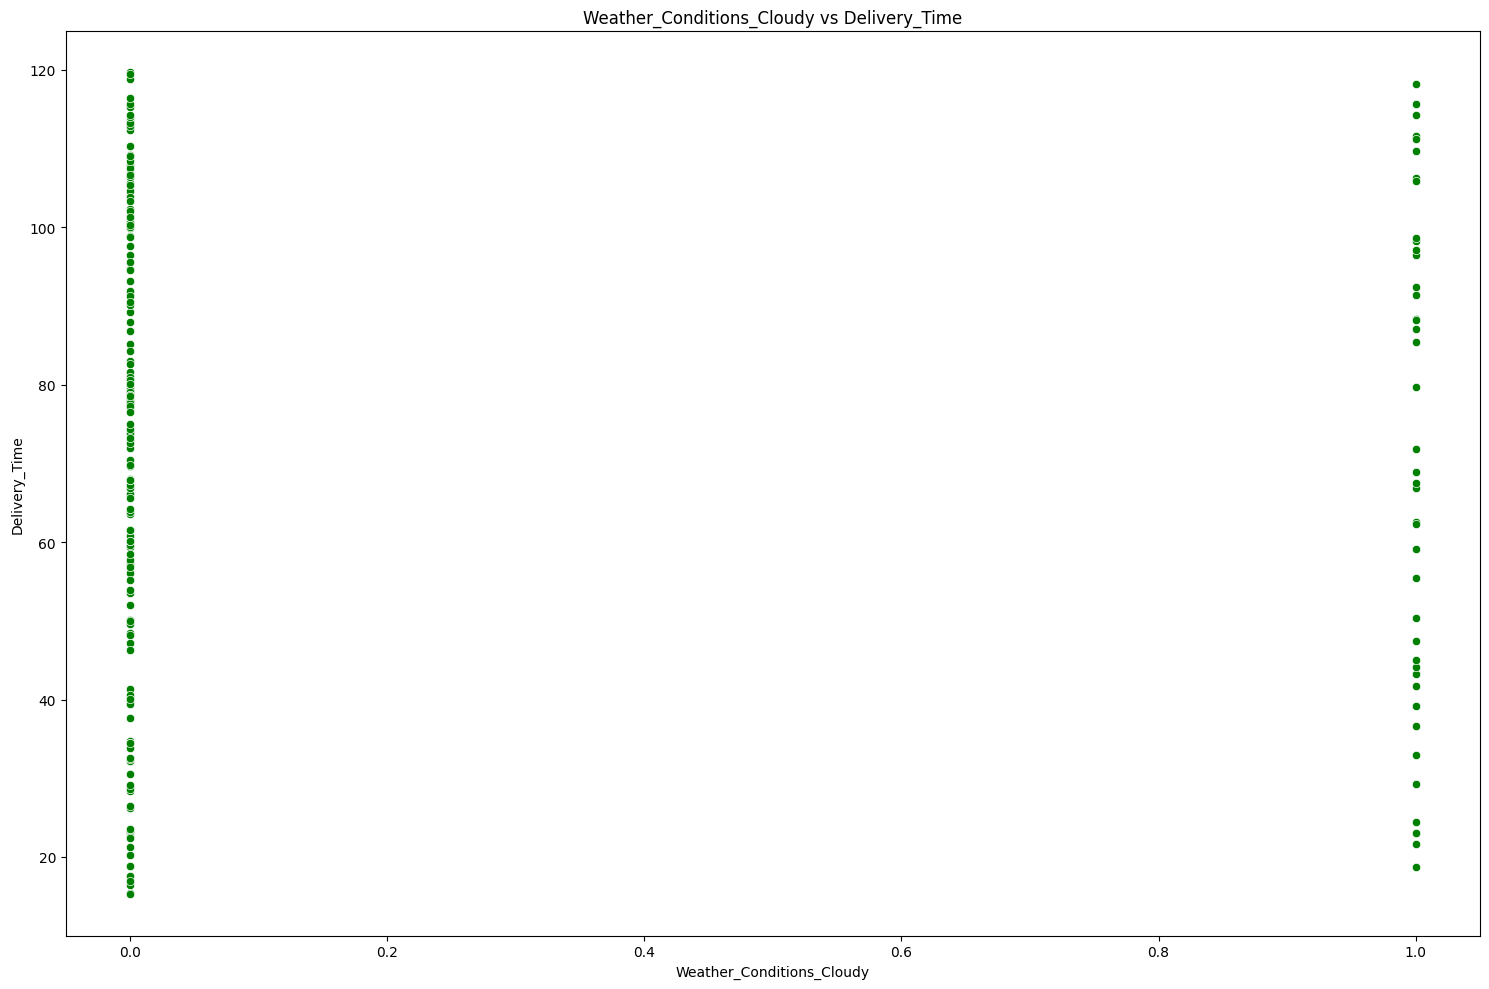

Saved to -> ..\outputs\plots\\Weather_Conditions_Rainy_vs_deliverytime_scatterplot.png


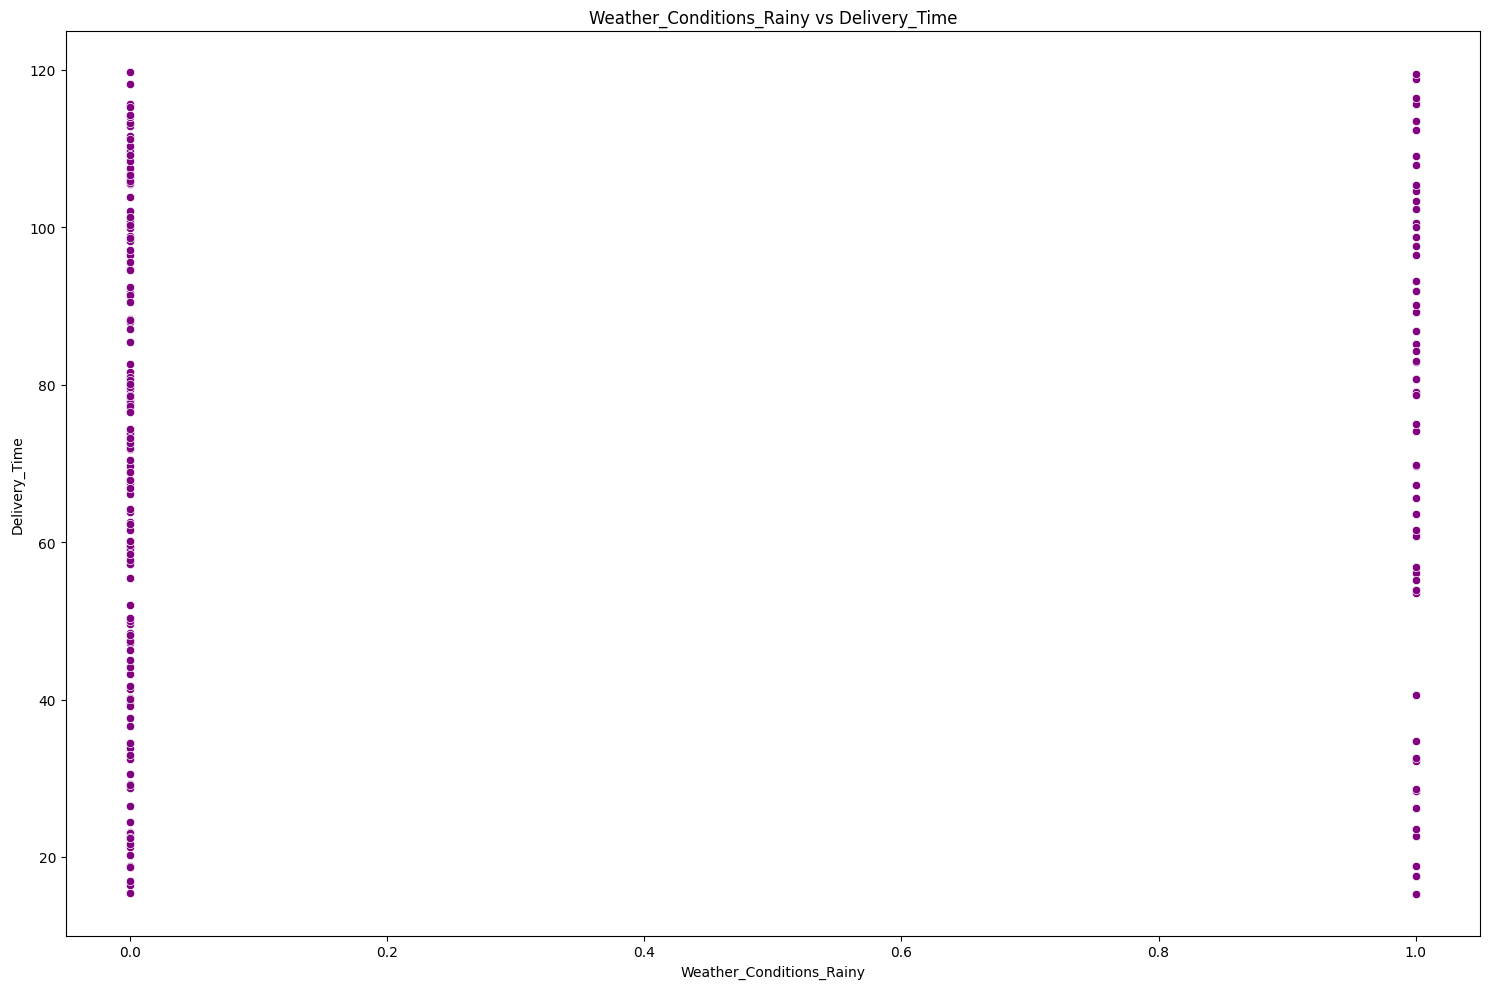

Saved to -> ..\outputs\plots\\Weather_Conditions_Snowy_vs_deliverytime_scatterplot.png


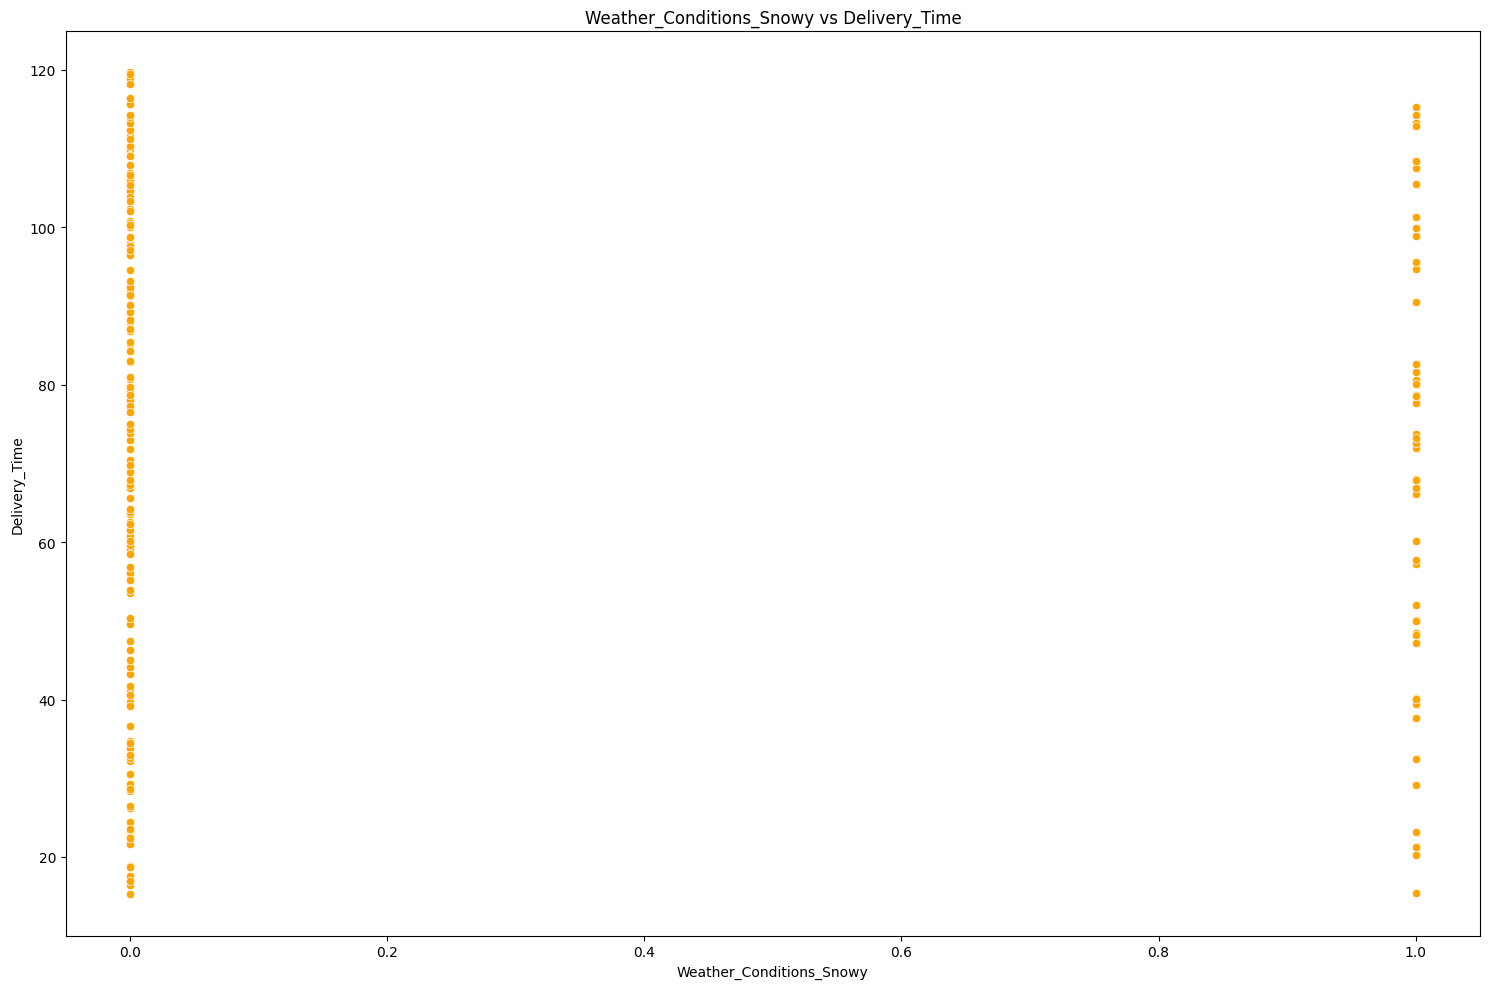

Saved to -> ..\outputs\plots\\Weather_Conditions_Sunny_vs_deliverytime_scatterplot.png


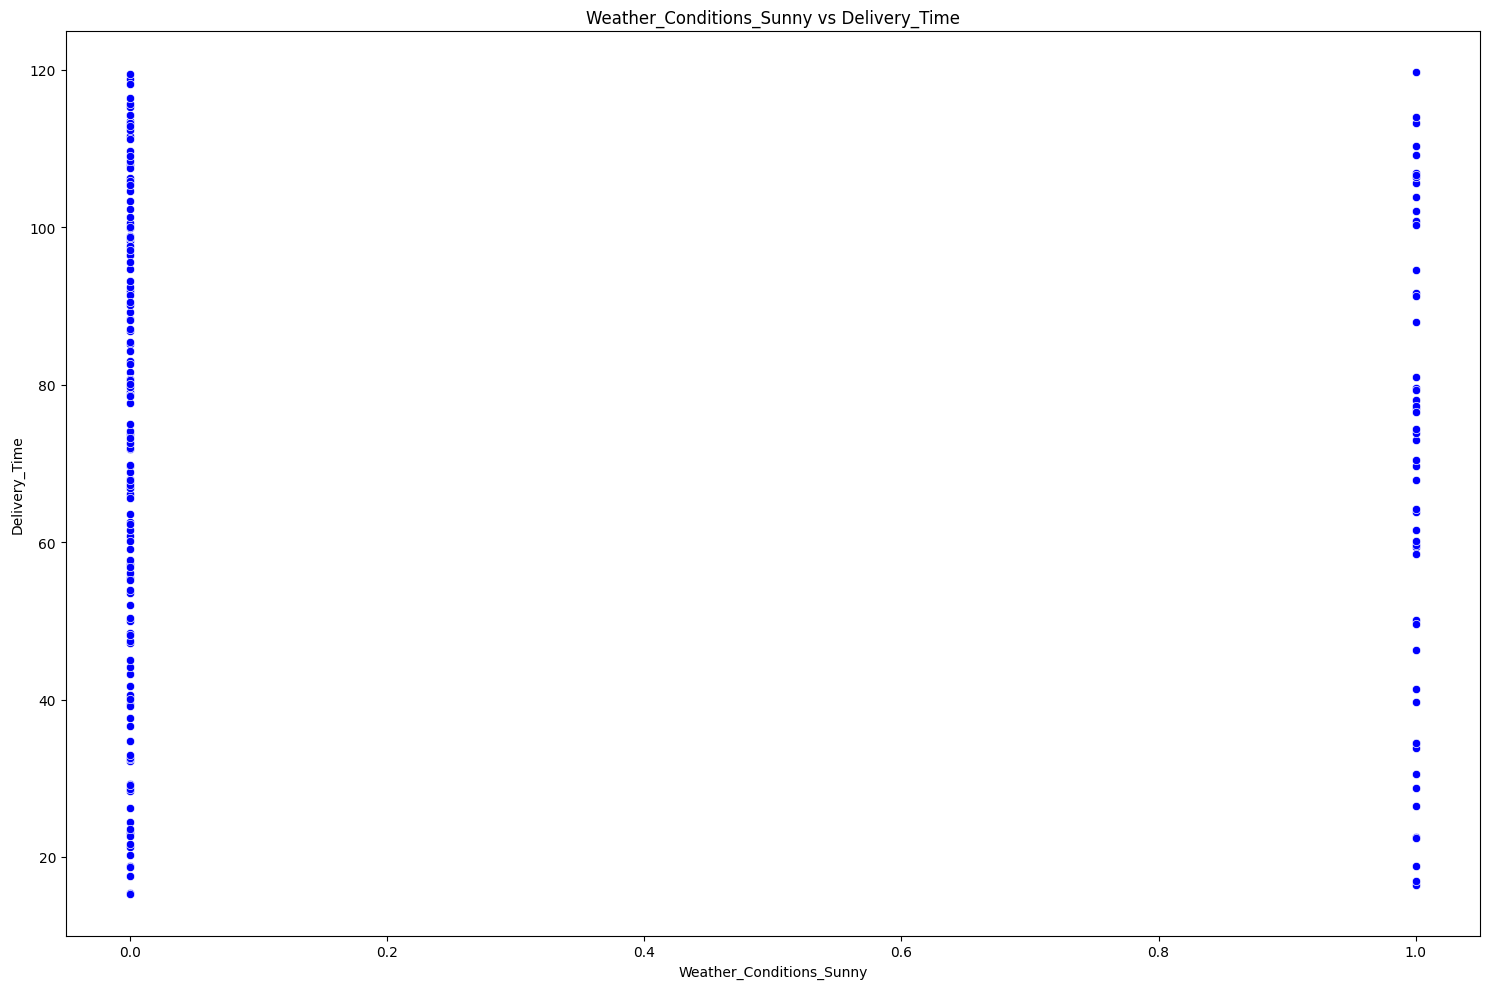

Saved to -> ..\outputs\plots\\Order_Time_Afternoon_vs_deliverytime_scatterplot.png


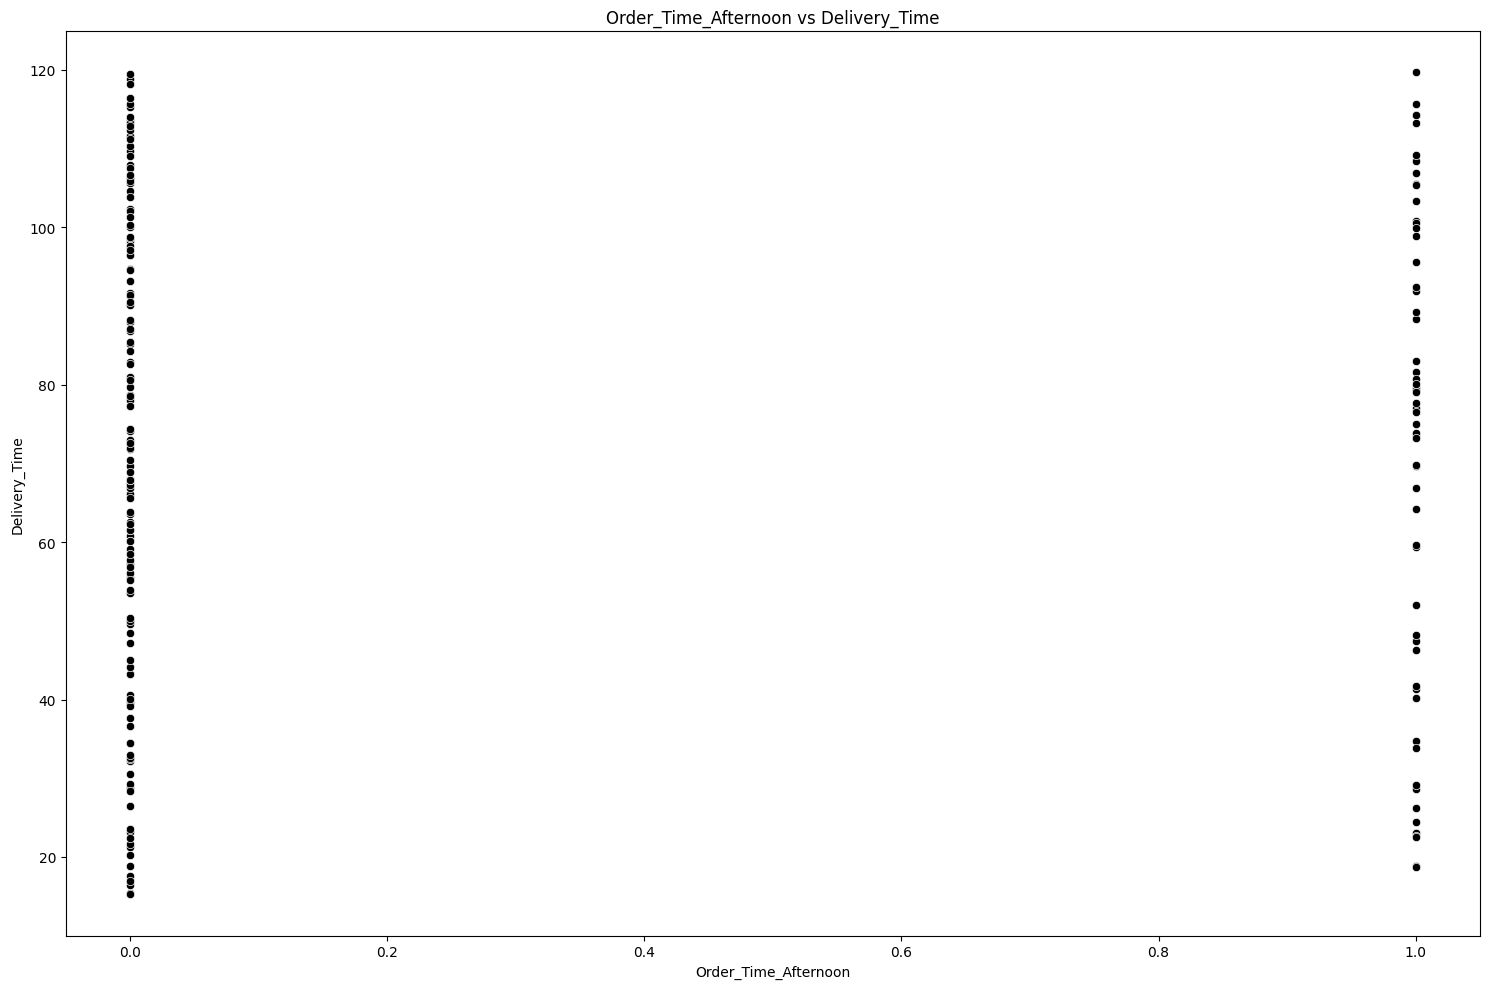

Saved to -> ..\outputs\plots\\Order_Time_Evening_vs_deliverytime_scatterplot.png


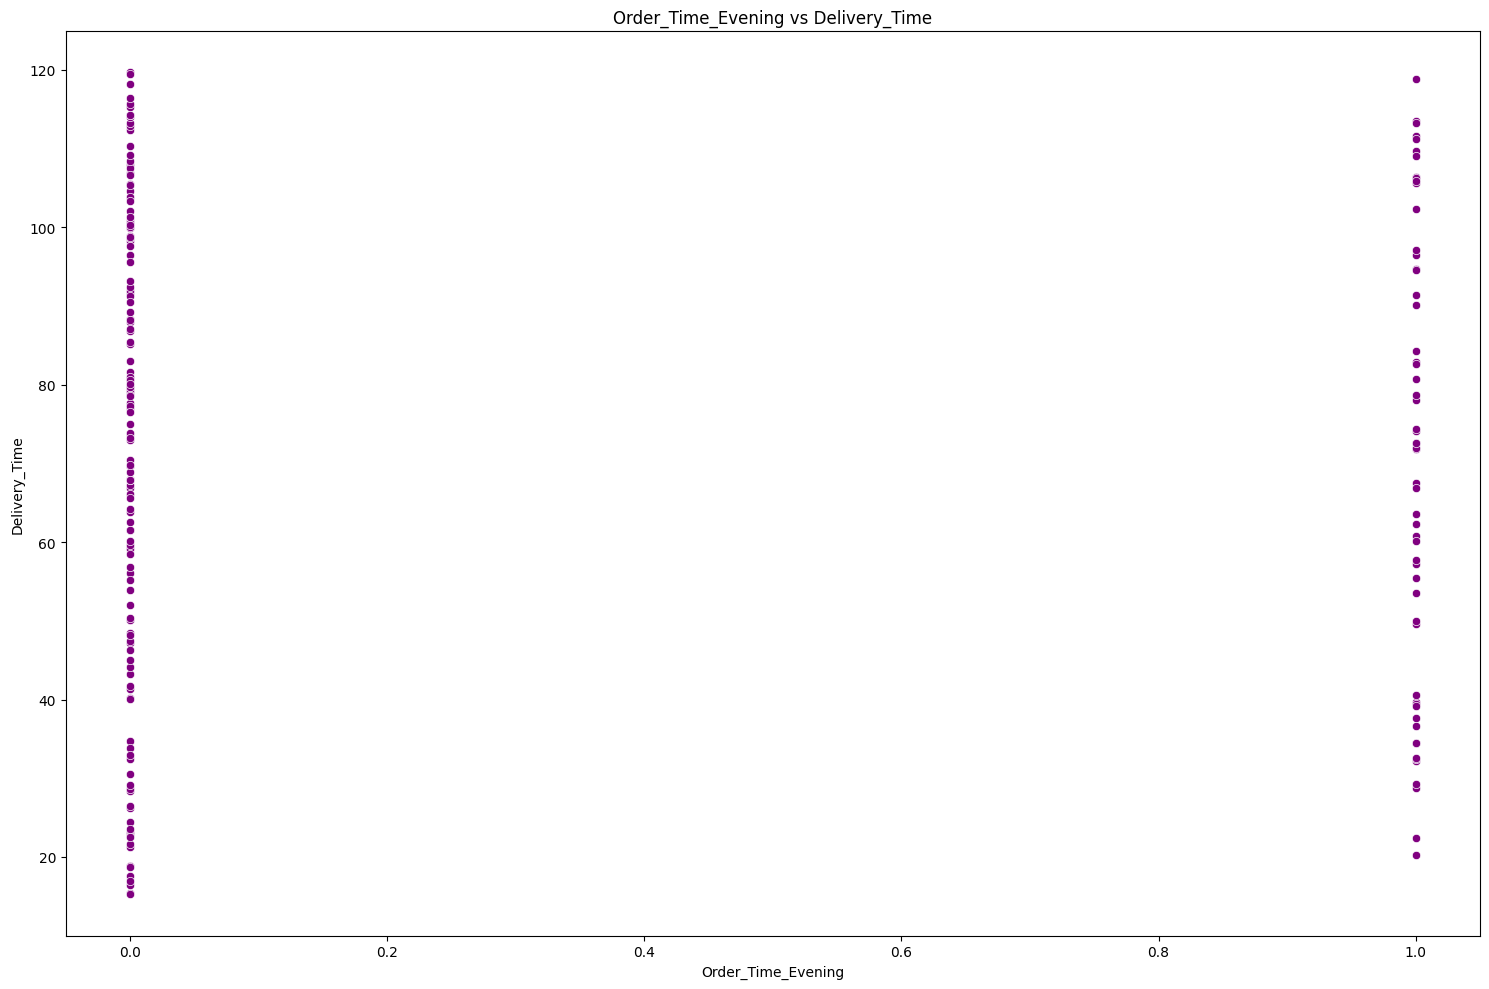

Saved to -> ..\outputs\plots\\Order_Time_Morning_vs_deliverytime_scatterplot.png


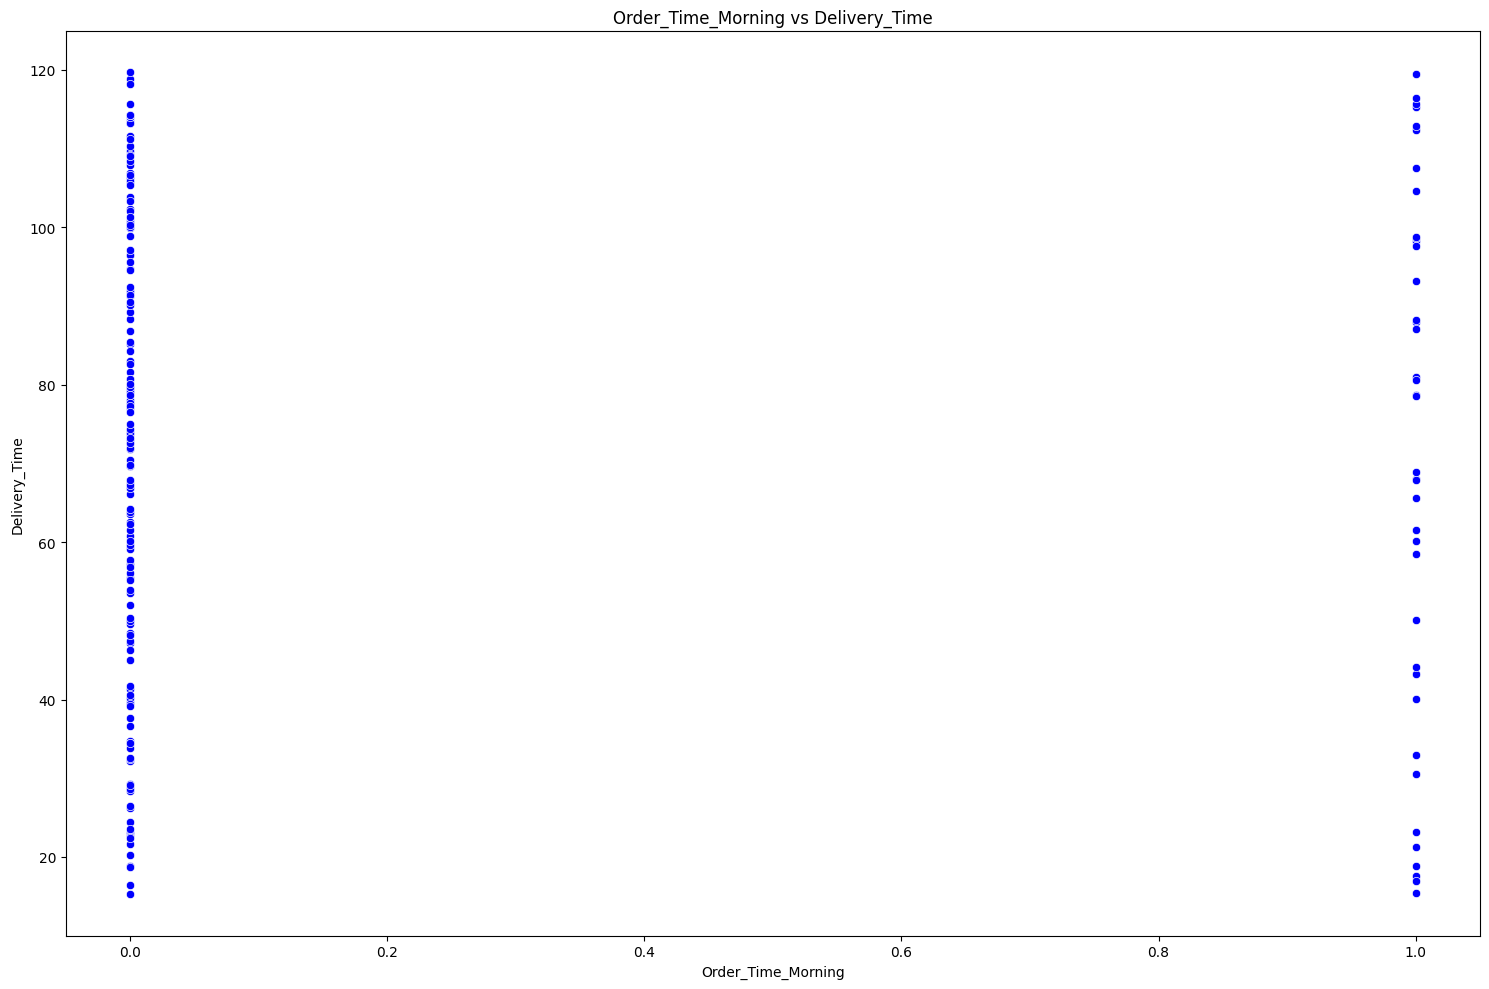

Saved to -> ..\outputs\plots\\Order_Time_Night_vs_deliverytime_scatterplot.png


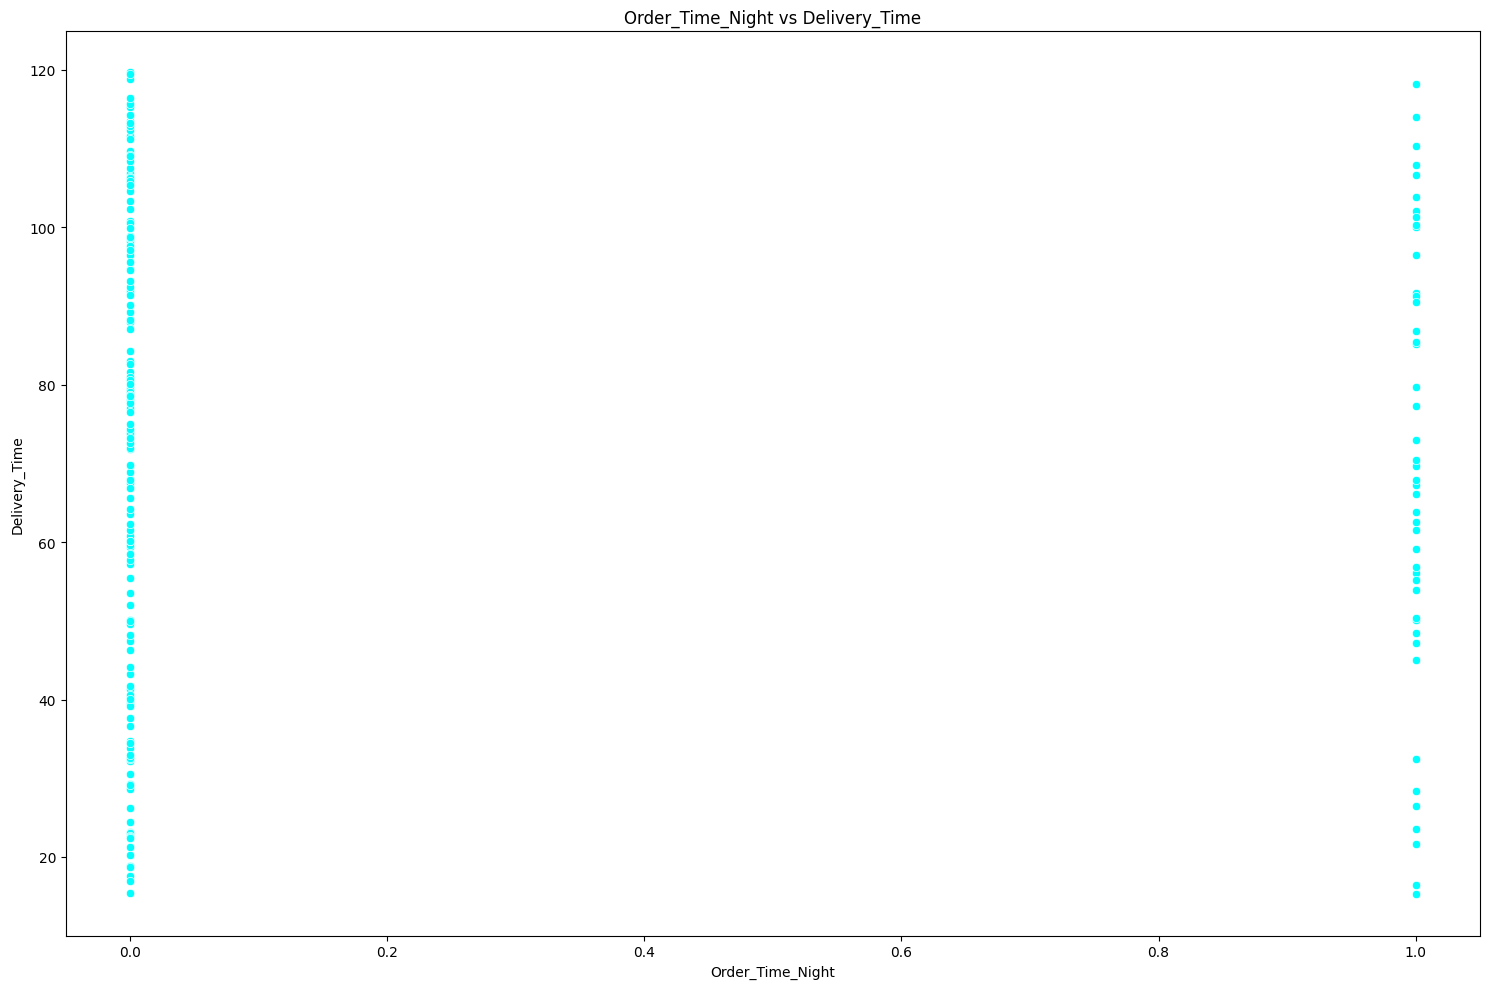

Saved to -> ..\outputs\plots\\Vehicle_Type_Bicycle_vs_deliverytime_scatterplot.png


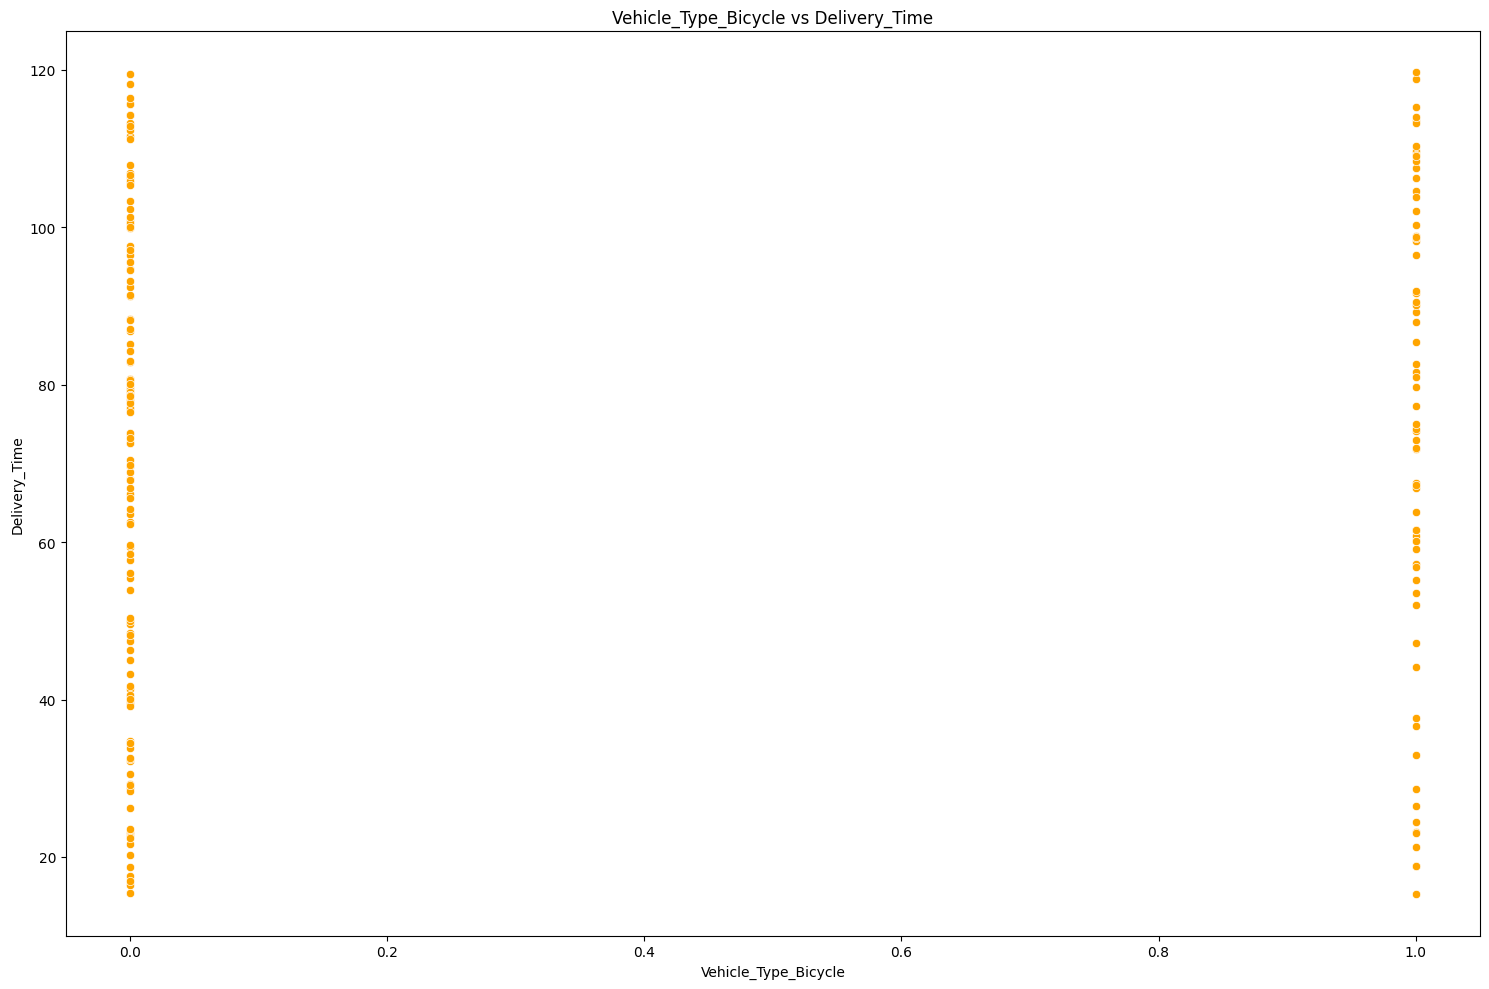

Saved to -> ..\outputs\plots\\Vehicle_Type_Bike_vs_deliverytime_scatterplot.png


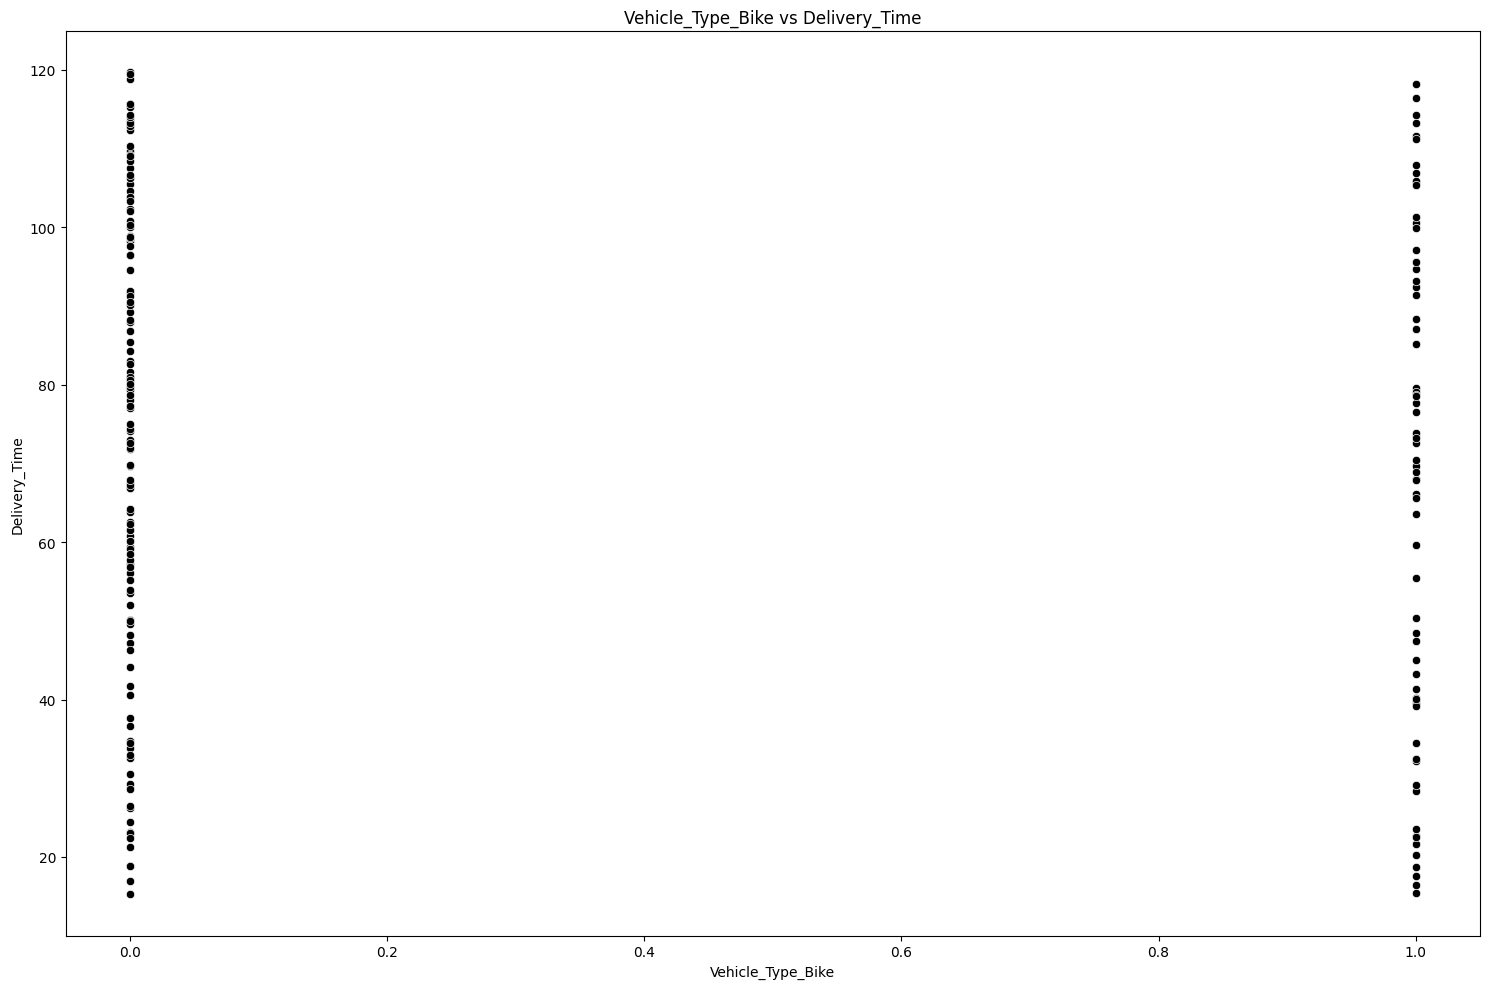

Saved to -> ..\outputs\plots\\Vehicle_Type_Car_vs_deliverytime_scatterplot.png


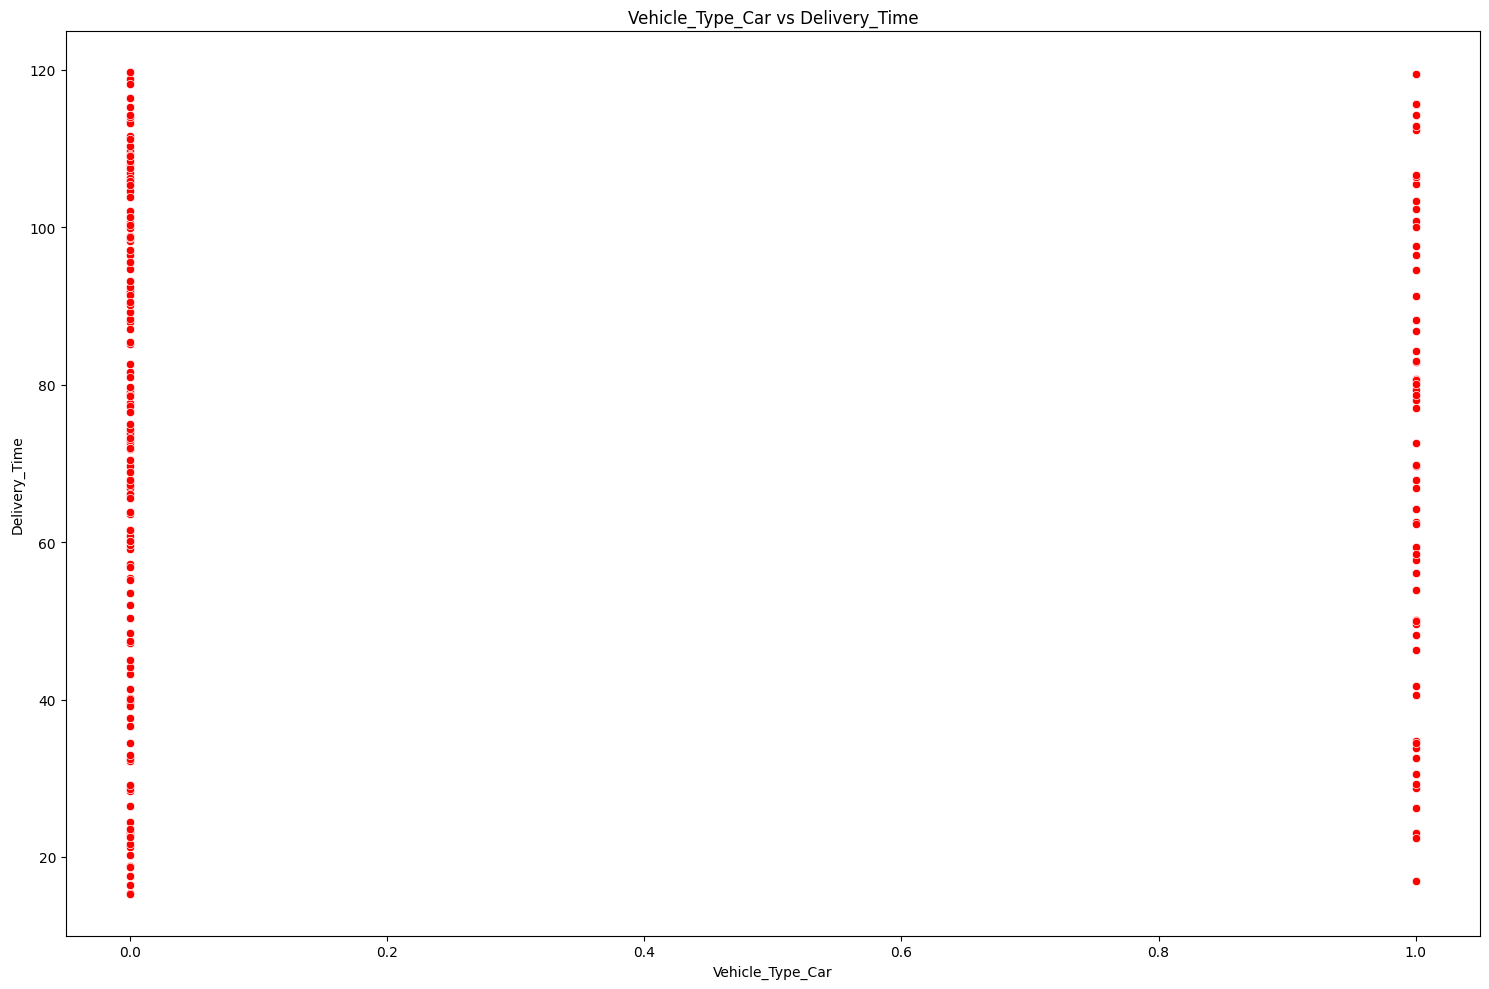

Saved to -> ..\outputs\plots\\distance_calculated_vs_deliverytime_scatterplot.png


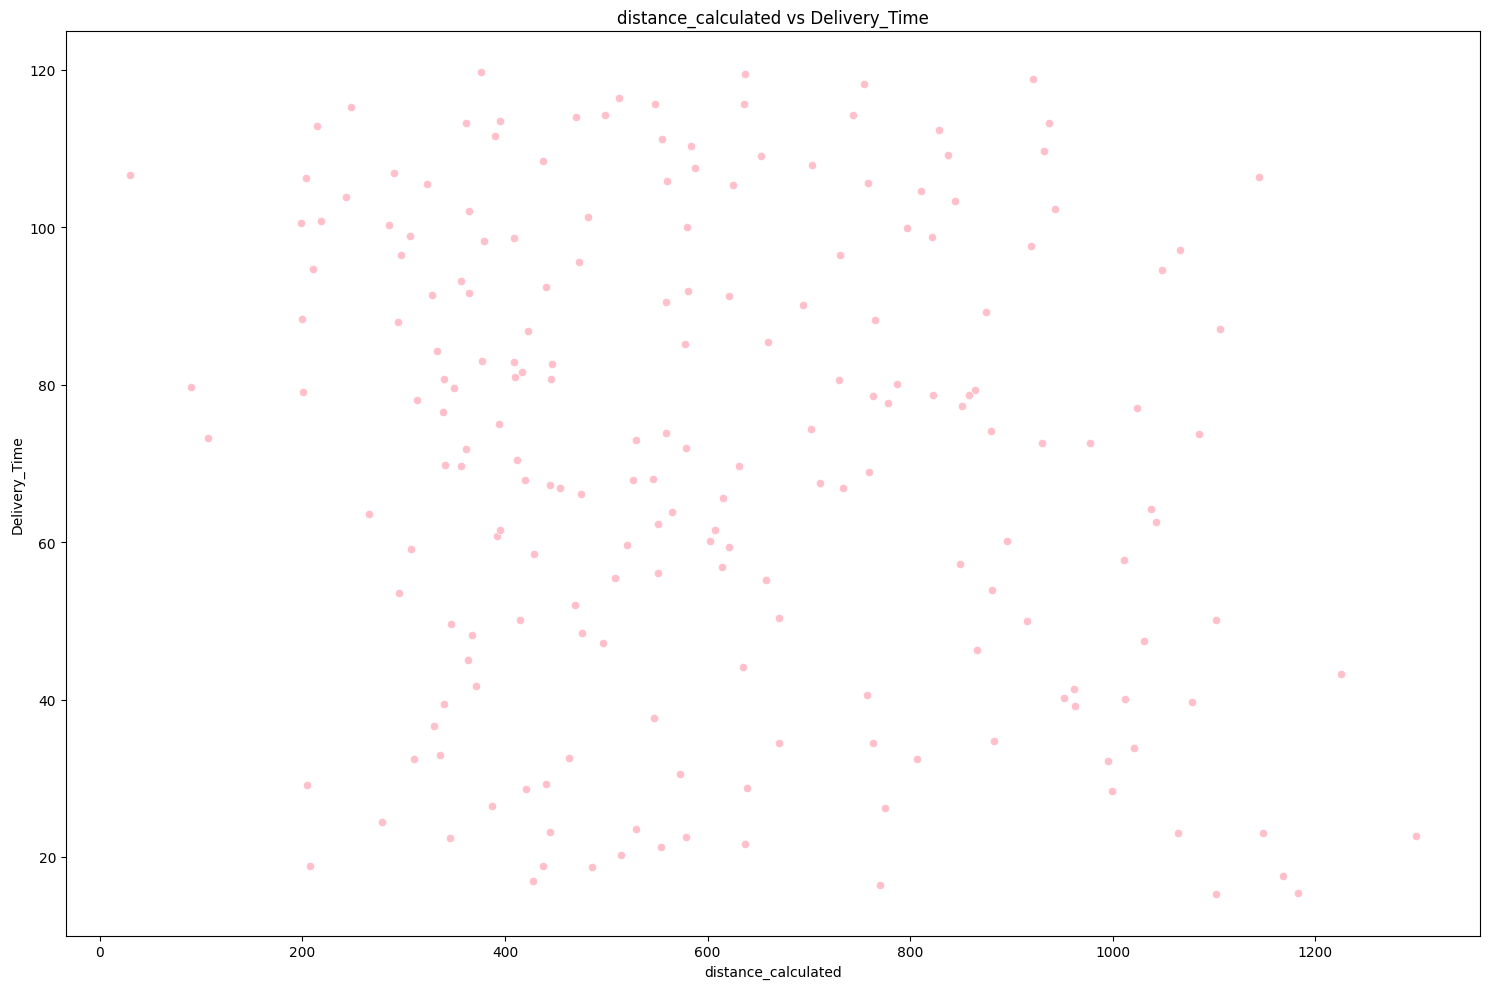

Saved to -> ..\outputs\plots\\is_peak_hour_vs_deliverytime_scatterplot.png


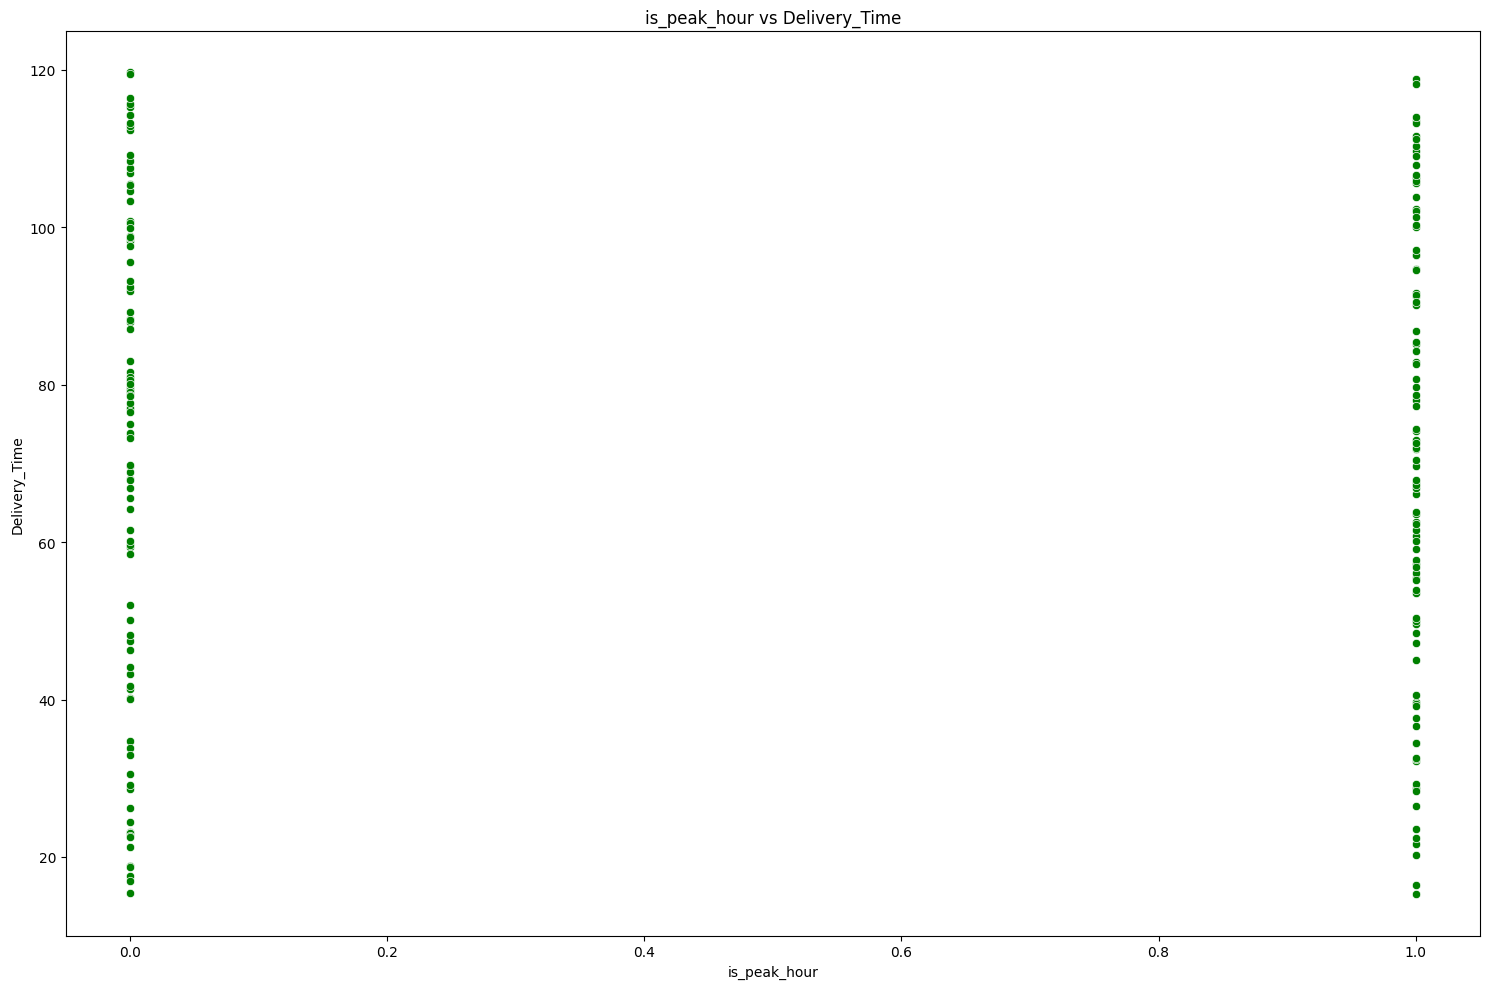

In [35]:
import random

c = ['red', 'blue', 'green', 'orange', 'purple', 'black', 'pink', 'cyan', 'yellow']

for i in x:
    plt.figure(figsize=(15,10))
    sns.scatterplot(x = df[i], y =df['Delivery_Time'], color = random.choices(c))
    plt.title(f"{i} vs Delivery_Time")
    plt.xlabel(i)
    plt.ylabel("Delivery_Time")
    plt.tight_layout()
    save_plot(f'{i}_vs_deliverytime_scatterplot.png')
    plt.show()

In [36]:
score_linear = r2_score(y_test, pred_linear)
print(f'Linear Regression R2 Score: {score_linear}')
print('-'*20)
train_score_linear = model.score(x_train, y_train)
test_score_linear = model.score(x_test, y_test)
print(f"Linear Regression Model Taining score is {train_score_linear}")
print('-'*20)
print(f"Linear Regression Model testing score is {test_score_linear}")
print('-'*20)
mse_linear = mean_squared_error(y_test, pred_linear)
print(f'Linear Regression MSE: {mse_linear}')
print('-'*20)
mae_linear = mean_absolute_error(y_test, pred_linear)
print(f'Linear Regression MAE: {mae_linear}')
print('-'*20)
rmse_linear = root_mean_squared_error(y_test, pred_linear)
print(f'Linear Regression RMSE: {rmse_linear}')

Linear Regression R2 Score: -0.03229943419126369
--------------------
Linear Regression Model Taining score is 0.06125582038120825
--------------------
Linear Regression Model testing score is -0.03229943419126369
--------------------
Linear Regression MSE: 954.7646721908047
--------------------
Linear Regression MAE: 26.561914601843977
--------------------
Linear Regression RMSE: 30.89926653159917


In [37]:
if score_linear <= 0.5:
    print('Model not performing well...')
    print('Chose another model...')
else:
    print('Model performing well...\n')
print('--'*20)
print('Hence from above scatter plot we can get the decision that' \
'Linear model cannot perform well')

Model not performing well...
Chose another model...
----------------------------------------
Hence from above scatter plot we can get the decision thatLinear model cannot perform well


___

# ***logistic Regression***

In [38]:
# Creating a new feature delivery status
threshold = df['Delivery_Time'].median()

df['Delivery_Status'] = np.where(df['Delivery_Time'] <= threshold, 0, 1)
# 0 = Fast, 1 = Delayed

In [39]:
df.head()

,Distance,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Rush_Hour,...,Order_Time_Afternoon,Order_Time_Evening,Order_Time_Morning,Order_Time_Night,Vehicle_Type_Bicycle,Vehicle_Type_Bike,Vehicle_Type_Car,distance_calculated,is_peak_hour,Delivery_Status
0,1.57,1,4,1,4.1,3.0,26.22,1321.10,81.54,0,...,1,0,0,0,0,0,1,775.651198,0,0
1,21.32,1,8,0,4.5,4.2,62.61,152.21,29.02,1,...,0,0,0,1,0,0,1,1042.385597,1,0
2,6.95,1,9,2,3.3,3.4,48.43,1644.38,64.17,1,...,0,0,0,1,0,1,0,476.220706,1,0
3,13.79,0,2,1,3.2,3.7,111.63,541.25,79.23,1,...,0,1,0,0,0,1,0,389.912629,1,1
4,6.72,2,6,0,3.5,2.8,32.38,619.81,2.34,1,...,0,0,0,1,0,1,0,806.505886,1,0


In [40]:
print('Declaring features and target')
x = df.drop(columns=['Delivery_Time', 'Delivery_Status'])
y = df['Delivery_Status']
print('Features and targets declared...')
print('*'*20)

Declaring features and target
Features and targets declared...
********************


In [41]:
print('Performing the split..')
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print('Split completed..')
print('-'*20)

# Using standardization on feature
print('Performing standardization..')
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print('Standardization completed..')
print('-'*20)

print('Creating model..')
print('Declaring hyperparameters....')
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}
print('Hyperparameters declared...')
print('Selecting best parameters')
grid_logistic = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',   
    n_jobs=-1
)

grid_logistic.fit(x_train, y_train)
best_model_logistic = grid_logistic.best_estimator_
print(f'Best parameters are: {best_model_logistic}')
print('Model created...')
print('-'*20)


Performing the split..
Split completed..
--------------------
Performing standardization..
Standardization completed..
--------------------
Creating model..
Declaring hyperparameters....
Hyperparameters declared...
Selecting best parameters
Best parameters are: LogisticRegression(C=0.01, max_iter=1000, penalty='l2')
Model created...
--------------------


c:\Program Files\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [42]:
print('Predicting....')
pred_logistic = best_model_logistic.predict(x_test)
print('Prediction Completed...')
print('-'*20)

print("Logistic Best Params:", grid_logistic.best_params_)
print('-'*20)

logistic_accuracy = accuracy_score(y_test, pred_logistic)
print("Logistic Accuracy:", logistic_accuracy)
print('-'*20)

logistic_precision = precision_score(y_test, pred_logistic)
print("Logistic Precision:", logistic_precision)
print('-'*20)

logistic_recall = recall_score(y_test, pred_logistic)
print("Logistic Logistic Recall:", logistic_recall)
print('-'*20)

logistic_f1 = f1_score(y_test, pred_logistic)
print("Logistic F1 Score:", logistic_f1)
print('-'*20)

logistic_classificatio_report = classification_report(y_test, pred_logistic)
print("\nLogistic Regression Classification Report:\n", logistic_classificatio_report)
print('-'*20)

cm_logistic = confusion_matrix(y_test, pred_logistic)
print("\nLogistic Regression Confusion Matrix:\n", cm_logistic)
print('-'*20)

Predicting....
Prediction Completed...
--------------------
Logistic Best Params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
--------------------
Logistic Accuracy: 0.5
--------------------
Logistic Precision: 0.5238095238095238
--------------------


Logistic Logistic Recall: 0.5238095238095238
--------------------
Logistic F1 Score: 0.5238095238095238
--------------------

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.47      0.47        19
           1       0.52      0.52      0.52        21

    accuracy                           0.50        40
   macro avg       0.50      0.50      0.50        40
weighted avg       0.50      0.50      0.50        40

--------------------

Logistic Regression Confusion Matrix:
 [[ 9 10]
 [10 11]]
--------------------


Saved to -> ..\outputs\plots\\Logistic_Regression_confusion_Matrix.png


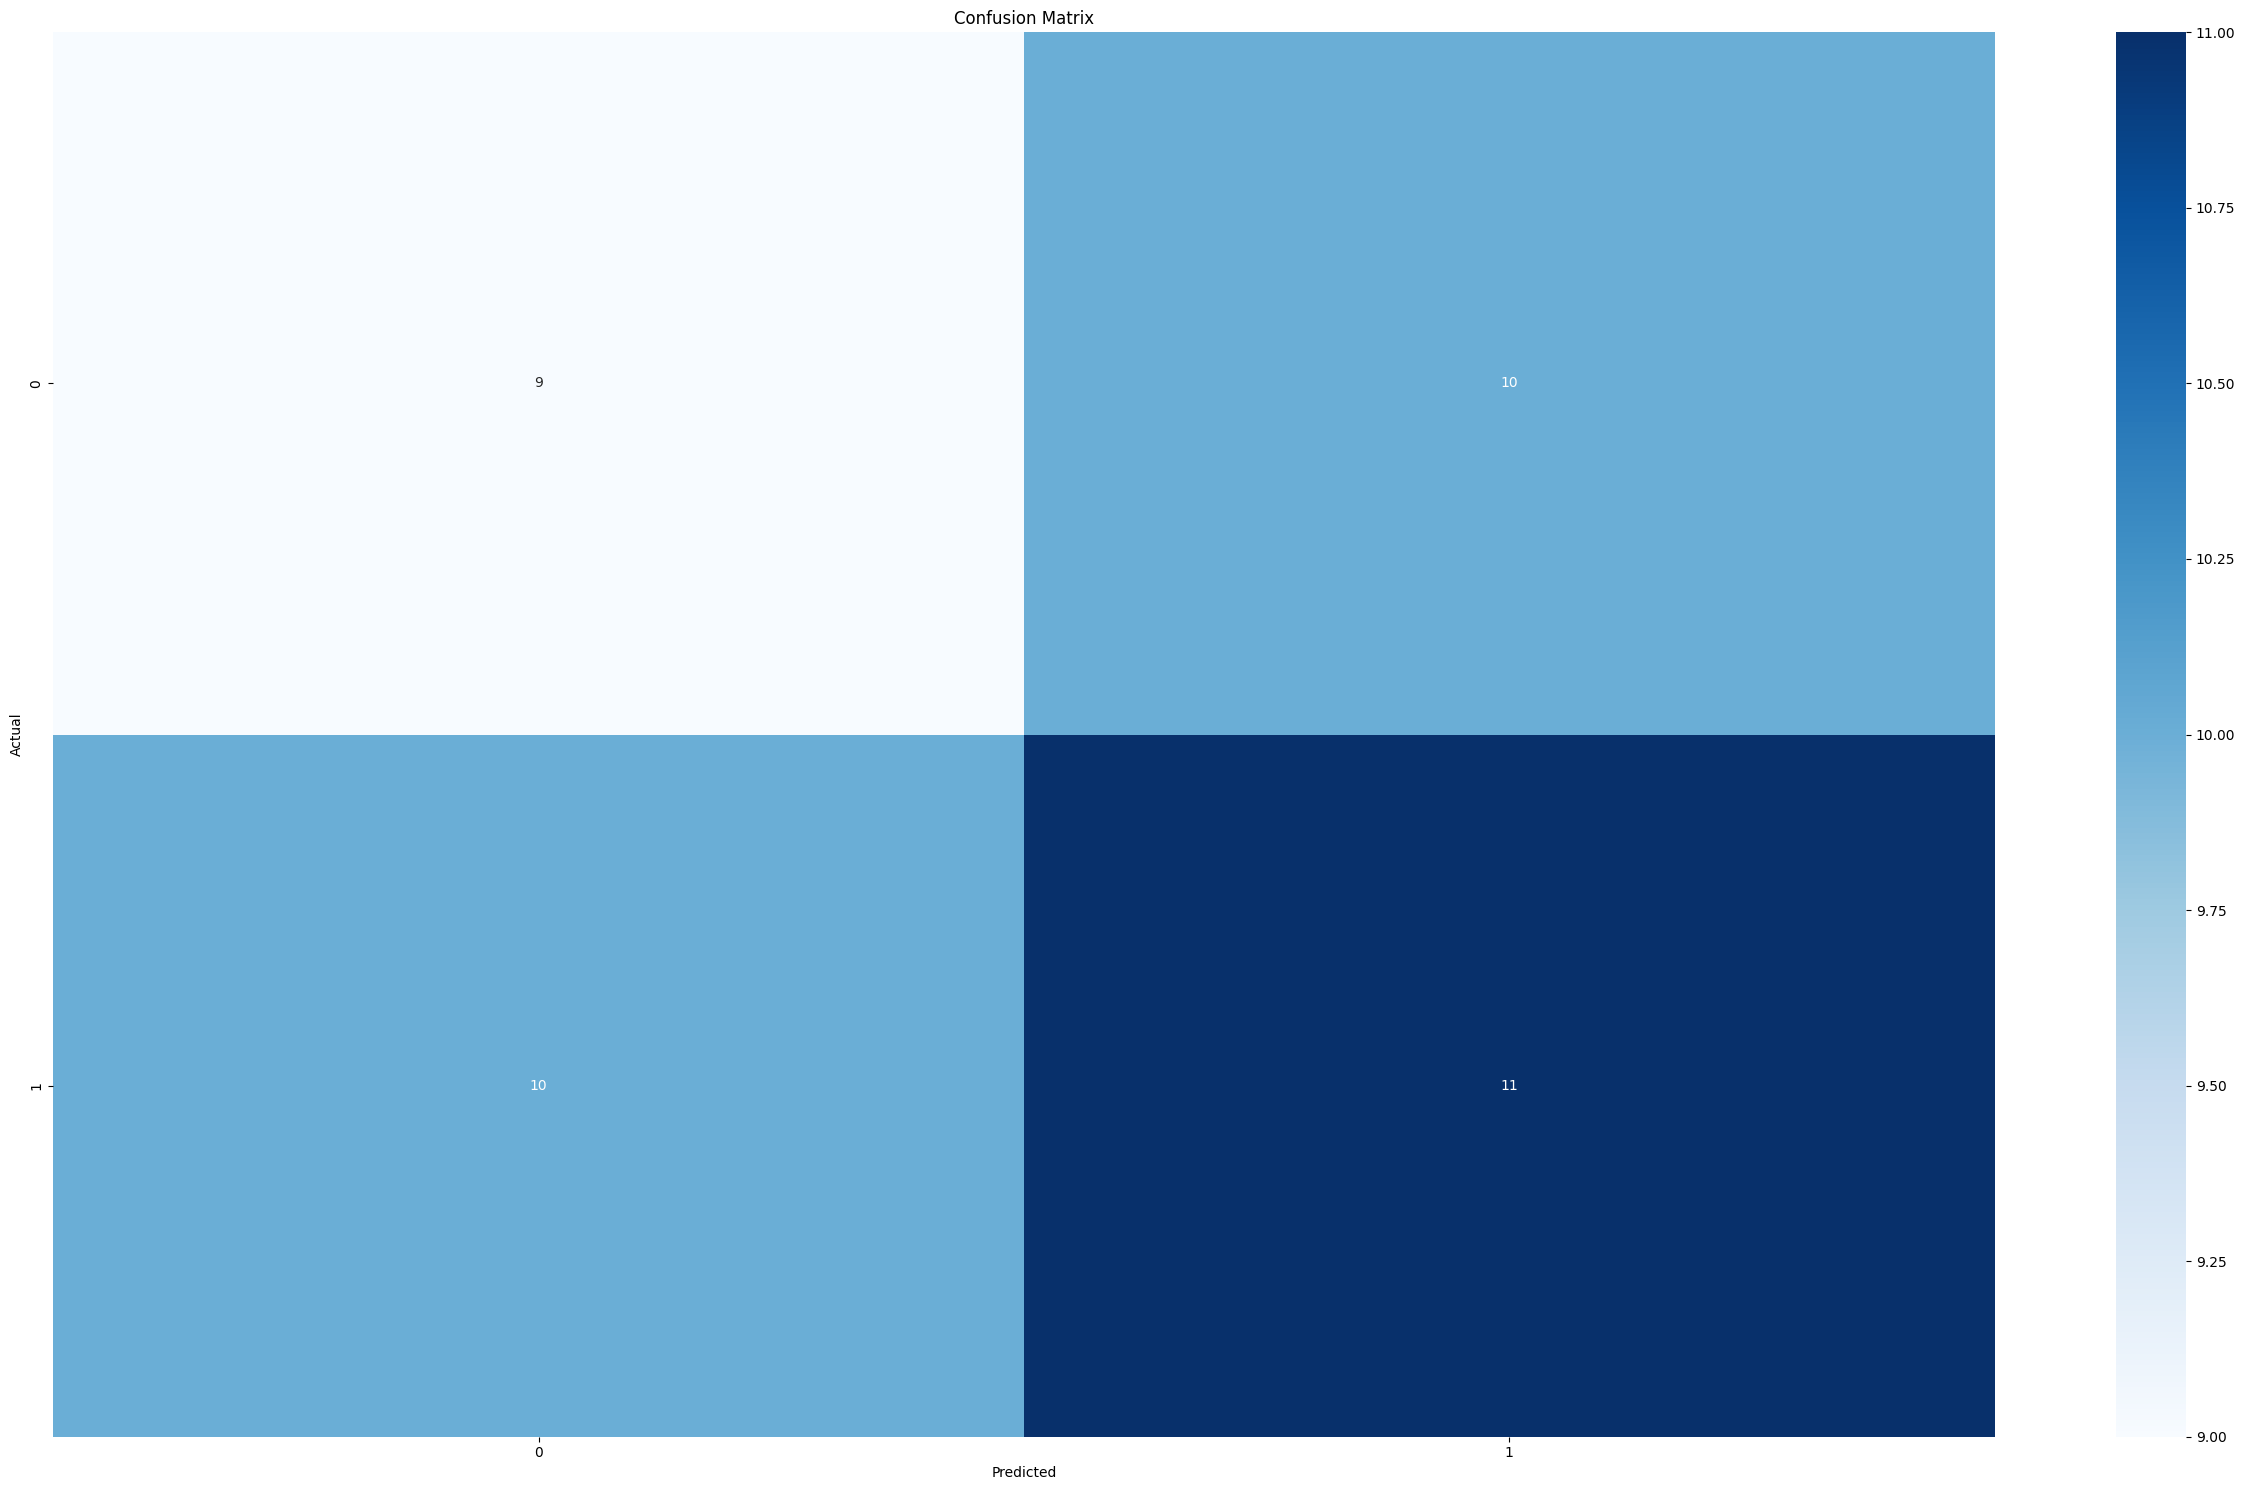

In [43]:
plt.figure(figsize=(25,15))
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
save_plot('Logistic_Regression_confusion_Matrix.png')
plt.show()

In [44]:
print("Checking best parameters in logistic regression....")
importance = pd.Series(
    abs(best_model_logistic.coef_[0]),
    index=x.columns
).sort_values(ascending=False)

print(f'Important features are in Logistic Regression are: \n{importance.head(10)}')

Checking best parameters in logistic regression....
Important features are in Logistic Regression are: 
distance_calculated           0.065939
Weather_Conditions_Rainy      0.061174
Delivery_Person_Experience    0.060760
Distance                      0.058758
Vehicle_Type_Bicycle          0.058449
Weather_Conditions_Cloudy     0.050236
Traffic_Conditions            0.048225
Order_Time_Night              0.044806
Tip_Amount                    0.038637
is_peak_hour                  0.036930
dtype: float64


____

# ***Random Forest Regressor***

In [45]:
print('Declaring features and target')
x = df.drop(columns=['Delivery_Time'])
y = df['Delivery_Time']
print('Features and targets declared...')
print('*'*20)

Declaring features and target
Features and targets declared...
********************


In [46]:
print('Performing the split..')
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
print('Split completed..')
print('-'*20)

Performing the split..
Split completed..
--------------------


In [47]:
print('Selecting parameters...')
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
print("Checking best parameters in logistic regression....")

grid_rfr = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_rfr.fit(x_train, y_train)

rfr_best_model = grid_rfr.best_estimator_
print(f'Best parameters are: {rfr_best_model}')

Selecting parameters...
Checking best parameters in logistic regression....
Best parameters are: RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, random_state=42)


In [48]:
print('Predicting.....')
rfr_pred = rfr_best_model.predict(x_test)
print('Prediction completed...')
print('-'*20)

rfr_r2 = r2_score(y_test, rfr_pred)
print("Random Forest Regressor R2 Score:", rfr_r2)
print('-'*20)

rfr_train_score = grid_rfr.score(x_train,y_train)
print(f"Random Forest Regressor Training Score: {rfr_train_score}")
print('-'*20)

rfr_test_score = grid_rfr.score(x_test,y_test)
print(f"Random Forest Regressor Testiing Score: {rfr_test_score}")
print('-'*20)

rfr_mae = mean_absolute_error(y_test, rfr_pred)
print(f"Random Forest Regressor Random Forest Regressor MAE: {rfr_mae}")
print('-'*20)

rfr_mse = mean_squared_error(y_test, rfr_pred)
print(f"Random Forest Regressor Random Forest Regressor MSE: {rfr_mse}")
print('-'*20)

rfr_rmse = root_mean_squared_error(y_test, rfr_pred)
print("Random Forest Regressor RMSE:", rfr_rmse)
print('-'*20)

Predicting.....
Prediction completed...
--------------------
Random Forest Regressor R2 Score: 0.7340737969041387
--------------------
Random Forest Regressor Training Score: 0.9261598950483403
--------------------
Random Forest Regressor Testiing Score: 0.7340737969041387
--------------------
Random Forest Regressor Random Forest Regressor MAE: 13.551736861396773
--------------------
Random Forest Regressor Random Forest Regressor MSE: 245.9528076024535
--------------------
Random Forest Regressor RMSE: 15.682882630513229
--------------------


In [49]:
print('Checking important features....')
rfr_importance = pd.Series(
    rfr_best_model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)

print('Important features in Random forest regression:\n',rfr_importance.head(10))

Checking important features....
Important features in Random forest regression:
 Delivery_Status               0.749705
Tip_Amount                    0.045661
Distance                      0.033920
Restaurant_Rating             0.030166
Order_Cost                    0.028879
distance_calculated           0.025364
Customer_Rating               0.016998
Delivery_Person_Experience    0.016876
Traffic_Conditions            0.008977
Order_Priority                0.006401
dtype: float64


Plotting random Forest.....
Saved to -> ..\outputs\plots\\random_forest_regressor.png


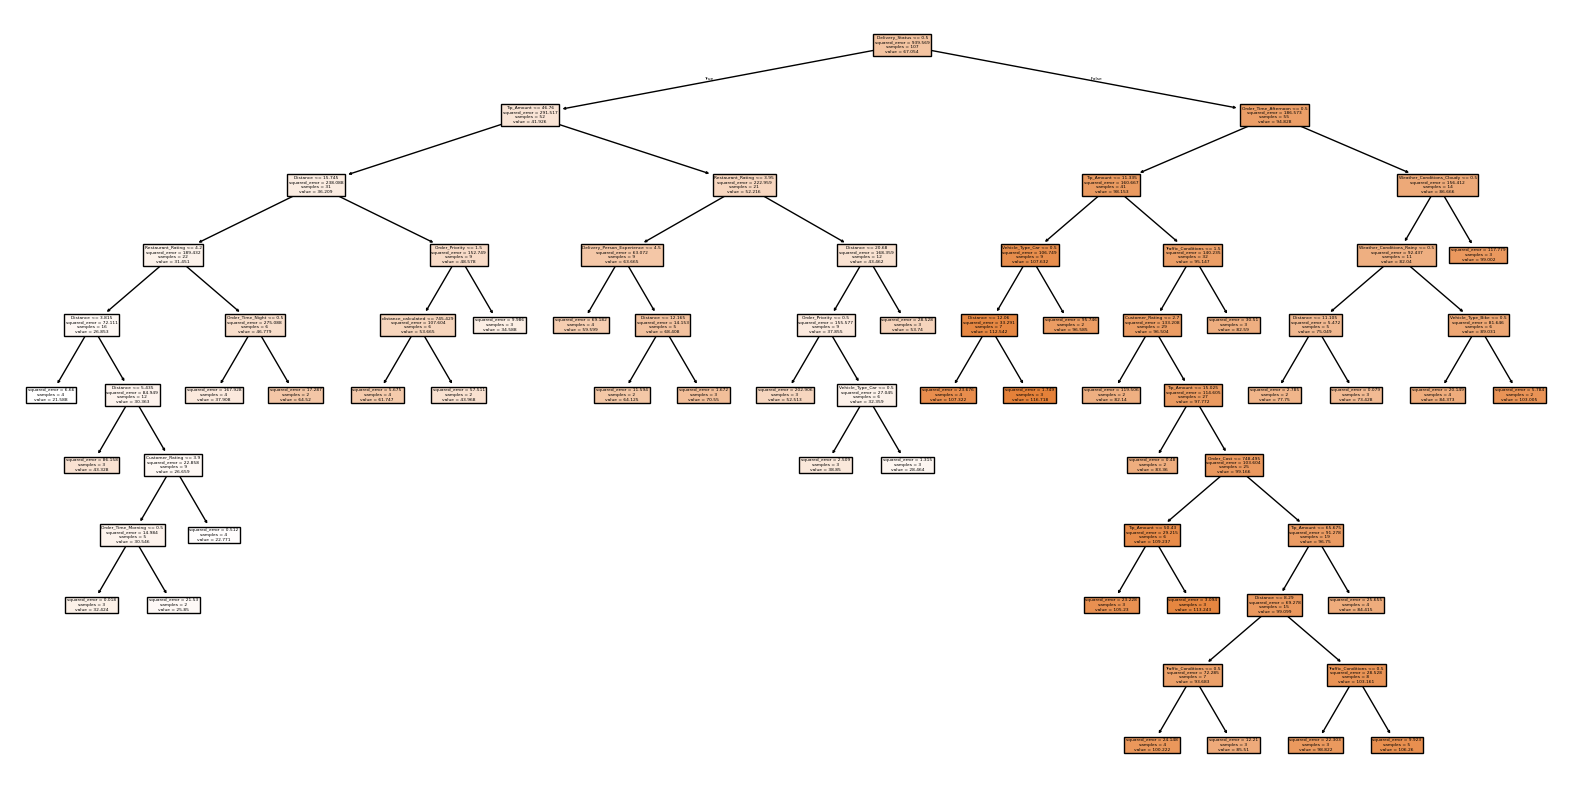

In [50]:
print('Plotting random Forest.....')
tree = grid_rfr.best_estimator_[0]

plt.figure(figsize=(20,10))
plot_tree(tree, filled=True, feature_names=x.columns)
save_plot('random_forest_regressor.png')
plt.show()